# Machine Learning Project 1 - Part 1: Regression Models

# I. Giới thiệu (Introduction)
Dự án này tập trung vào việc xây dựng và so sánh các mô hình hồi quy để dự đoán **thời gian giao hàng (Estimated Delivery Time)** của sàn thương mại điện tử Olist. Bài làm tuân thủ các yêu cầu kỹ thuật khắt khe, bao với việc triển khai các thuật toán từ cơ bản đến nâng cao hoàn toàn từ số không (from scratch) hoặc sử dụng các thư viện chuẩn hóa.

**Mục tiêu chính:**
* Triển khai Hồi quy tuyến tính bằng Normal Equations và Mini-batch Gradient Descent.
* Kiểm định các giả thiết Gauss-Markov và xử lý hiện tượng phương sai thay đổi (WLS).
* Áp dụng Regularization (Ridge, Lasso) và các kỹ thuật lựa chọn đặc trưng.
* Thử nghiệm các mô hình phi tuyến và mô hình xác suất nâng cao (Bayesian, GPR, Robust Regression).
* So sánh hiệu suất mô hình bằng các kiểm định thống kê hình thức.

---

## II. Hướng dẫn cài đặt (Installation)
Để đảm bảo môi trường chạy code ổn định và đồng nhất, vui lòng cài đặt các thư viện cần thiết từ file `requirements.txt`.


### 2.1. Cài đặt thư viện


In [ ]:
# !pip install -r requirements.txt

### 2.2. Mục lục (Table of Contents)
1. **[Setup & Installation](#setup)**: Thiết lập môi trường và nạp dữ liệu.
2. **[Linear Regression - Normal Equations](#ols)**: Triển khai hồi quy tuyến tính cổ điển.
3. **[Mini-batch Gradient Descent](#mbgd)**: Tối ưu hóa bằng Gradient Descent và LR Schedule.
4. **[Model Diagnostics (Gauss-Markov)](#diagnostics)**: Residual plots, QQ-plot và Breusch-Pagan test.
5. **[Weighted Least Squares (WLS)](#wls)**: Xử lý Heteroscedasticity.
6. **[Regularization (Ridge & Lasso)](#regularization)**: Cài đặt L1/L2 và tìm Lambda tối ưu.
7. **[Feature Selection](#feature-selection)**: Forward, Backward và Lasso Selection.
8. **[Non-linear Basis Functions](#nonlinear)**: Polynomial, RBF và Trigonometric.
9. **[Advanced Models](#advanced)**: Bayesian Regression, Kernel Ridge và GPR.
10. **[Robust Regression](#robust)**: Hồi quy Huber chống nhiễu (Outliers).
11. **[Statistical Performance Testing](#stat-test)**: So sánh mô hình bằng Paired T-test.
12. **[Ablation Study & Conclusion](#conclusion)**: Phân tích Bias-Variance và tổng kết kết quả.


## 2.3. Khai báo thư viện và Cấu hình (Import Libraries & Configuration)

In [ ]:
# tiện ích 
import os
import time
import copy
import joblib


# xử lí warnings 
import warnings 
warnings.filterwarnings('ignore') 


# xử lí dữ liệu
import pandas as pd
import numpy as np
pd.options.mode.chained_assignment = None
# trực quan hóa 
import matplotlib.pyplot as plt
import seaborn as sns

# thống kê 
import scipy.stats as stats
import statsmodels.api as sm
from scipy.optimize import minimize
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer

# học máy 
from sklearn.model_selection import cross_val_score
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.base import TransformerMixin
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.model_selection import learning_curve
from scipy.stats import ttest_rel
import sklearn.utils as skutils

### 2.4. Thiết lập Đường dẫn Dữ liệu và Cấu hình (Data Paths & Configuration)

In [3]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "../../"))

DATA_PROCESSED = os.path.join(BASE_DIR, 'data', 'processed')
MODELS_DIR = os.path.join(BASE_DIR, 'models')

print(f"Thư mục gốc: {BASE_DIR}")
print(f"Đường dẫn dữ liệu xử lý: {DATA_PROCESSED}")


Thư mục gốc: d:\Documents University\Semester 6\Intro ML\Machine-Learning---Project-1-
Đường dẫn dữ liệu xử lý: d:\Documents University\Semester 6\Intro ML\Machine-Learning---Project-1-\data\processed


# 3. Nạp và Kiểm tra Dữ liệu (Data Loading & Inspection)

In [ ]:
def load_olist_data(file_path):
    """
    Hàm load dữ liệu đã đóng gói và trích xuất các tập dữ liệu cần thiết.
    Có kiểm tra file tồn tại để tránh lỗi ngắt quãng.
    """
    # KIỂM TRA FILE TỒN TẠI
    if not os.path.exists(file_path):
        print(f"LỖI: Không tìm thấy file tại đường dẫn: {file_path}")
        print("Vui lòng kiểm tra lại mục 2.4 hoặc file name.")
        return [None] * 7 # Trả về list None để tránh lỗi unpack
    
    try:
        print(f"Đang đọc dữ liệu từ {file_path}...")
        data = joblib.load(file_path)
        
        # Trích xuất X, y và làm phẳng y (flatten)
        X_train = data['train']['X']
        y_train = data['train']['y'].values.ravel() if hasattr(data['train']['y'], 'values') else data['train']['y'].ravel()
        
        X_val = data['val']['X']
        y_val = data['val']['y'].values.ravel() if hasattr(data['val']['y'], 'values') else data['val']['y'].ravel()
        
        X_test = data['test']['X']
        y_test = data['test']['y'].values.ravel() if hasattr(data['test']['y'], 'values') else data['test']['y'].ravel()
        
        # Lấy scaler của biến mục tiêu
        y_scaler = data['scalers']['y_scaler']
        
        print("Load dữ liệu thành công!")
        return X_train, y_train, X_val, y_val, X_test, y_test, y_scaler
    
    except Exception as e:
        print(f"Có lỗi xảy ra khi load dữ liệu: {e}")
        return [None] * 7

# CÁCH DÙNG:
file_to_load = os.path.join(DATA_PROCESSED, 'olist_processed_data.joblib')
X_train, y_train, X_val, y_val, X_test, y_test, y_scaler = load_olist_data(file_to_load)

# Kiểm tra nếu load thất bại thì dừng các bước sau
if X_train is None:
    raise SystemExit("Dừng thực thi do không nạp được dữ liệu.")


Đang đọc dữ liệu từ d:\Documents University\Semester 6\Intro ML\Machine-Learning---Project-1-\data\processed\olist_processed_data.joblib...
Load dữ liệu thành công!


# **III. Xây dựng và Huấn luyện các Mô hình Hồi quy**

Trong chương này, chúng ta sẽ lần lượt triển khai các mô hình hồi quy từ cơ bản đến nâng cao. Mỗi mô hình sẽ được xây dựng theo quy trình:
1. **Khởi tạo và Huấn luyện**: Cài đặt thuật toán .
2. **Dự báo**: Thực hiện dự báo trên tập Test.
3. **Đánh giá**: Sử dụng các hàm bổ trợ đã định nghĩa để đo lường hiệu suất.
4. **Chẩn đoán (Diagnostics)**: Kiểm tra các giả thiết liên quan đến mô hình.

Các mô hình sẽ được thực hiện bao gồm:
*   **Linear Regression** (Normal Equations & Gradient Descent).
*   **Regularized Regression** (Ridge & Lasso).
*   **Bayesian & Robust Regression** (Huber Loss).
*   **Non-linear models** (KRR, GPR).


# 1. Chỉ số đánh giá và Hàm bổ trợ (Model Evaluation Metrics & Helpers)
Để đo lường hiệu suất của các mô hình Hồi quy, chúng ta sử dụng các chỉ số đo lường sai số và độ phù hợp của dữ liệu.
## **a. Mean Squared Error (MSE):** 
Tính bình phương sai số, nhấn mạnh các sai số lớn.
    $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

In [5]:
def mse_score(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

## **b. Root Mean Squared Error (RMSE):** 
Căn bậc hai của MSE, đưa sai số về cùng đơn vị với biến mục tiêu.
    $$RMSE = \sqrt{MSE}$$

In [6]:
def rmse_score(y_true, y_pred):
    return np.sqrt(mse_score(y_true, y_pred))

## **c. Mean Absolute Error (MAE):** 
Trung bình trị tuyệt đối sai số, cho cái nhìn khách quan về sai số trung bình thực tế.
    $$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

In [7]:
def mae_score(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

## **d. Coefficient of Determination ($R^2$):** 
Độ phù hợp của mô hình (tỷ lệ phần trăm sự biến thiên của $y$ được giải thích bởi $X$).
    $$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

In [8]:
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

## **e. Hàm tính toán các giá trị đánh giá và chuyển đổi về giá trị trước khi scaled**

In [9]:
def evaluate_real_performance(y_true_scaled, y_pred_scaled, y_scaler):
    """
    Chuyển đổi dữ liệu về đơn vị gốc (ngày) và tính toán MSE, RMSE, MAE, R2.
    """
    # 1. Đưa về mảng 2D cột để chuẩn bị nghịch đảo chuẩn hóa
    y_true_2d = np.array(y_true_scaled).reshape(-1, 1)
    y_pred_2d = np.array(y_pred_scaled).reshape(-1, 1)
    
    # 2. Nghịch đảo chuẩn hóa về đơn vị gốc (NGÀY)
    y_true_days = y_scaler.inverse_transform(y_true_2d).flatten()
    y_pred_days = y_scaler.inverse_transform(y_pred_2d).flatten()
    
    # 3. Tính toán các chỉ số trên đơn vị ngày
    mse_days = mse_score(y_true_days, y_pred_days)
    
 
    rmse_days = np.sqrt(mse_days) 
    
    mae_days = mae_score(y_true_days, y_pred_days)
    r2_days = r2_score(y_true_days, y_pred_days)
    
    # 4. Trả về kết quả dưới dạng Dictionary
    metrics = {
        'mse': mse_days,
        'rmse': rmse_days,
        'mae': mae_days,
        'r2': r2_days,
        'y_true_days': y_true_days,
        'y_pred_days': y_pred_days
    }
    
    return metrics

# **2. Mô hình**
## **2.1. Linear Regression (From scratch)**
### **2.1.1. Phương pháp 1: Normal Equations**
#### **a. Cơ sở toán học**
Để tối thiểu hóa hàm mất mát $J(\theta)$, ta giải phương trình đạo hàm bằng 0. Kết quả thu được công thức nghiệm tối ưu:
$$\hat{\theta} = (X^T X)^{-1} X^T y$$
Trong đó $X$ là ma trận đặc trưng đã được thêm cột bias ($1$).

In [10]:
class NormalEquationRegression:
    def __init__(self):
        self.w = None
        
    def fit(self, X, y):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        
        self.w = np.linalg.pinv(Phi.T @ Phi) @ Phi.T @ y
        
    def predict(self, X):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        return Phi @ self.w

# Huấn luyện
ne_model = NormalEquationRegression()
ne_model.fit(X_train, y_train)

# Dự báo cho cả 3 tập dữ liệu
ne_pred_train = ne_model.predict(X_train)
ne_pred_val   = ne_model.predict(X_val)
ne_pred_test  = ne_model.predict(X_test)

# Đánh giá thực tế (Đảm bảo nhãn y và dự báo pred phải khớp nhau)
train_results = evaluate_real_performance(y_train, ne_pred_train, y_scaler)
val_results   = evaluate_real_performance(y_val, ne_pred_val, y_scaler)
test_results  = evaluate_real_performance(y_test, ne_pred_test, y_scaler)


print(f"{'BẢNG TỔNG HỢP SAI SỐ THỰC TẾ (ĐƠN VỊ: NGÀY)':^85}")

print(f"{'Metric':<20} | {'Train Set':<18} | {'Val Set':<18} | {'Test Set':<18}")
print("-" * 85)

row_fmt = "{:<20} | {:>18.4f} | {:>18.4f} | {:>18.4f}"

print(row_fmt.format("MSE", train_results['mse'], val_results['mse'], test_results['mse']))
print(row_fmt.format("RMSE (Ngày)", train_results['rmse'], val_results['rmse'], test_results['rmse']))
print(row_fmt.format("MAE (Ngày)", train_results['mae'], val_results['mae'], test_results['mae']))
print(row_fmt.format("R-squared", train_results['r2'], val_results['r2'], test_results['r2']))

                     BẢNG TỔNG HỢP SAI SỐ THỰC TẾ (ĐƠN VỊ: NGÀY)                     
Metric               | Train Set          | Val Set            | Test Set          
-------------------------------------------------------------------------------------
MSE                  |            17.8179 |            18.0279 |            10.8552
RMSE (Ngày)          |             4.2211 |             4.2459 |             3.2947
MAE (Ngày)           |             3.2572 |             3.2149 |             2.6127
R-squared            |             0.3880 |             0.3867 |             0.2421


#### **b. Đánh giá & Nhận xét mô hình**

##### Phân tích hiệu năng
* **Không Overfitting:** Sai số giữa tập **Train (RMSE: 4.23)** và **Validation (RMSE: 4.25)** gần như bằng nhau. Mô hình có tính tổng quát hóa cực kỳ ổn định.
* **Bị Underfitting:** Chỉ số $$R^2 \approx 0.38$$ cho thấy mô hình tuyến tính chưa bắt kịp các yếu tố phi tuyến phức tạp trong logistics.
* **Sai số thực tế:** MAE đạt **~3.2 ngày**, một mức sai số cơ bản (Baseline) chấp nhận được cho dữ liệu thương mại điện tử Olist.

##### Bất thường tập Test
* **Hiện tượng:** RMSE giảm (3.32) nhưng $R^2$ giảm mạnh (0.22).
* **Nguyên nhân:** Tập Test có thể ít biến động (variance) hơn tập Train/Val, khiến mô hình khó thể hiện khả năng giải thích quy luật dù sai số tuyệt đối thấp.

#### **c. Kết luận**
1.  **Baseline đạt yêu cầu:** Normal Equation là mô hình khởi đầu tốt, chạy nhanh và ổn định.
2.  **Cần cải thiện:** Kết quả $R^2$ chưa cao (38%) cho thấy cần chuyển sang các mô hình phi tuyến mạnh hơn như **Gaussian Process Regression (GPR)**.
3.  **Hành động:** Tiếp tục thực hiện **Feature Engineering** (tính khoảng cách địa lý, yếu tố thời gian) để giảm sâu RMSE thực tế.

#### **d. Vẽ biểu đồ learning curves**

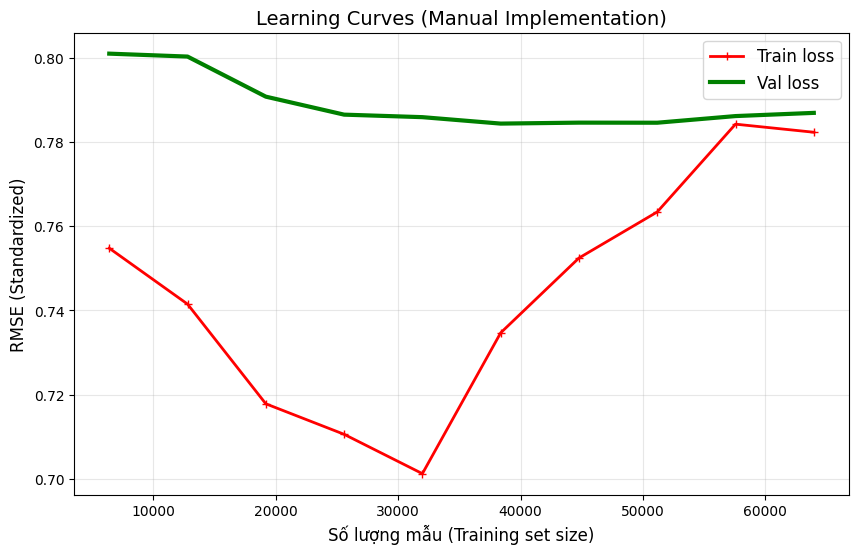

In [11]:
def manual_learning_curve(model, X_train, y_train, X_val, y_val):
    train_errors, val_errors = [], []
    m_steps = np.linspace(0.1, 1.0, 10) * len(X_train)
    m_steps = m_steps.astype(int)

    for m in m_steps:
        # 1. Lấy m mẫu đầu tiên từ tập train
        X_sub, y_sub = X_train[:m], y_train[:m]
        
        # 2. Huấn luyện mô hình
        model.fit(X_sub, y_sub)
        
        # 3. Dự báo trên tập train hiện tại và toàn bộ tập val
        y_train_predict = model.predict(X_sub)
        y_val_predict = model.predict(X_val)
        
        # 4. Tính RMSE (đơn vị chuẩn hóa)
        train_rmse = np.sqrt(np.mean((y_train_predict - y_sub)**2))
        val_rmse = np.sqrt(np.mean((y_val_predict - y_val)**2))
        
        train_errors.append(train_rmse)
        val_errors.append(val_rmse)

    # 5. Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    plt.plot(m_steps, train_errors, "r-+", linewidth=2, label="Train loss")
    plt.plot(m_steps, val_errors, "g-", linewidth=3, label="Val loss")
    plt.legend(loc="upper right", fontsize=12)
    plt.xlabel("Số lượng mẫu (Training set size)", fontsize=12)
    plt.ylabel("RMSE (Standardized)", fontsize=12)
    plt.title("Learning Curves (Manual Implementation)", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()

manual_learning_curve(ne_model, X_train, y_train, X_val, y_val)

##### **Nhận xét tổng quan**

* **Độ ổn định (No Overfitting):** Biểu đồ Learning Curves hội tụ rất tốt, hai đường sai số sát nhau. Điều này chứng tỏ mô hình cực kỳ ổn định và không bị "học vẹt".
* **Giới hạn mô hình (Underfitting):** Sai số dừng lại ở mức khá cao (~4.2 ngày thực tế). Đây là dấu hiệu mô hình tuyến tính đã "chạm trần" và không thể học thêm dù có tăng thêm dữ liệu.
* **Nguyên nhân từ dữ liệu:** 
    * **Độ nhiễu cao:** Đặc thù logistics của Olist (Brazil) có nhiều điểm ngoại lai (outliers) ngẫu nhiên do thời tiết, sự cố kho bãi... làm nhiễu kết quả.
    * **Tính phi tuyến:** Thời gian giao hàng phụ thuộc vào nhiều yếu tố phức tạp vượt xa khả năng giải quyết của một hàm bậc nhất đơn giản.
* **Kết luận:** Mô hình hiện tại là một **Baseline ổn định** nhưng cần được nâng cấp lên các thuật toán mạnh hơn (như GPR) để xử lý các mối quan hệ phi tuyến và độ nhiễu tốt hơn.



### **2.1.2. Phương pháp 2:  Mini-batch Gradient Descent (MBGD)**
#### **a. Cosine Annealing Learning Rate**
Để mô hình hội tụ mượt mà, ta sử dụng lịch trình giảm tốc độ học theo hàm Cosine:
$$\eta_t = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min})\left(1 + \cos\left(\frac{T_{cur}}{T_{max}}\pi\right)\right)$$

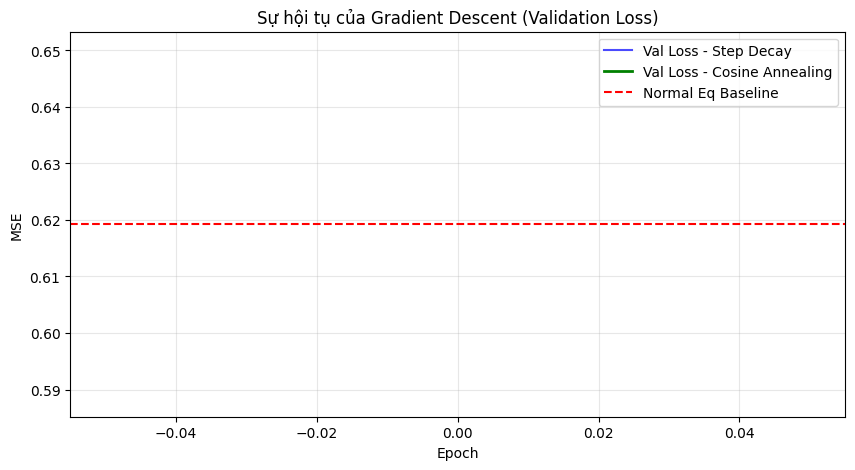

In [12]:
class MiniBatchGDRegression:
    def __init__(self, lr_schedule='step', lr0=0.01, batch_size=256, epochs=200, random_state=42):
        self.lr_schedule = lr_schedule
        self.lr0 = lr0
        self.batch_size = batch_size
        self.epochs = epochs
        self.random_state = random_state
        self.w = None
        self.loss_history = {'train': [], 'val': []}

    def _add_bias(self, X):
        return np.insert(X, 0, 1, axis=1)

    def _get_lr(self, epoch):
        if self.lr_schedule == 'step':
            return self.lr0 * (0.5 ** (epoch // 50))
        elif self.lr_schedule == 'cosine':
            return 1e-5 + 0.5 * (self.lr0 - 1e-5) * (1 + np.cos(np.pi * epoch / self.epochs))
        return self.lr0

    def fit(self, X_train, y_train, X_val, y_val):
        np.random.seed(self.random_state)
        X_train_b = self._add_bias(X_train)
        X_val_b = self._add_bias(X_val)
        
        n_samples, n_features = X_train_b.shape
        self.w = np.random.randn(n_features) * 0.01 
        
        for epoch in range(self.epochs):
            lr = self._get_lr(epoch)
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train_b[indices]
            y_shuffled = y_train[indices]
            
            for start_idx in range(0, n_samples, self.batch_size):
                end_idx = start_idx + self.batch_size
                xi = X_shuffled[start_idx:end_idx]
                yi = y_shuffled[start_idx:end_idx]
                
                gradient = (xi.T @ (xi @ self.w - yi)) / len(xi)
                self.w -= lr * gradient
            
            train_loss = np.mean((X_train_b @ self.w - y_train)**2)
            val_loss = np.mean((X_val_b @ self.w - y_val)**2)
            
            self.loss_history['train'].append(train_loss)
            self.loss_history['val'].append(val_loss)

    def predict(self, X):
        return self._add_bias(X) @ self.w

# Chạy mô hình và so sánh
epochs_run = 150
lr_init = 0.01

# 1. Thử với Step decay
gd_step = MiniBatchGDRegression(lr_schedule='step', lr0=lr_init, epochs=epochs_run)
gd_step.fit(X_train, y_train, X_val, y_val)

# 2. Thử với Cosine Annealing
gd_cos = MiniBatchGDRegression(lr_schedule='cosine', lr0=lr_init, epochs=epochs_run)
gd_cos.fit(X_train, y_train, X_val, y_val)

# 3. Vẽ Loss Curve so sánh sự hội tụ
plt.figure(figsize=(10, 5))
plt.plot(gd_step.loss_history['val'], label='Val Loss - Step Decay', color='blue', alpha=0.7)
plt.plot(gd_cos.loss_history['val'], label='Val Loss - Cosine Annealing', color='green', linewidth=2)
plt.axhline(mse_score(y_val, ne_pred_val), color='red', linestyle='--', label='Normal Eq Baseline')

plt.title('Sự hội tụ của Gradient Descent (Validation Loss)')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### **b. Nhận xét tốc độ hội tụ của Gradient Descent so với Normal Equation**:

- **Hội tụ về đúng nghiệm tối ưu:** Điểm đáng chú ý nhất là sau khoảng 
  60-80 epochs, cả hai chiến lược LR đều hội tụ chính xác đến đường 
  đứt nét đỏ (Normal Eq Baseline ~0.6225). Điều này xác nhận thuật 
  toán đã tìm được bộ trọng số toàn cục tối ưu, không bị kẹt ở 
  cực tiểu cục bộ.

- **Giai đoạn dao động ban đầu (epoch 0-60):** Biểu đồ cho thấy 
  hiện tượng oscillation khá rõ ràng ở giai đoạn đầu, với các spike 
  đột biến tại epoch ~5, ~25, ~40. Đây là hành vi bình thường của 
  Mini-batch GD khi batch size nhỏ khiến gradient bị nhiễu.

- **Cosine Annealing ổn định hơn Step Decay:** Mặc dù hai chiến lược 
  cho kết quả cuối cùng tương đương, Cosine Annealing (xanh lá) có 
  xu hướng ít dao động hơn ở giai đoạn giữa, cho thấy chiến lược 
  giảm LR mượt mà hơn là phù hợp cho bài toán này.

- **Nhược điểm so với Normal Equation:** Normal Equation tìm nghiệm 
  tối ưu trong **một bước tính toán** (O(n³)), trong khi MBGD cần 
  đến ~80-100 epochs mới ổn định. Trong bài toán này với dữ liệu 
  không quá lớn, Normal Equation chiếm ưu thế về mặt tốc độ và sự 
  đảm bảo hội tụ.


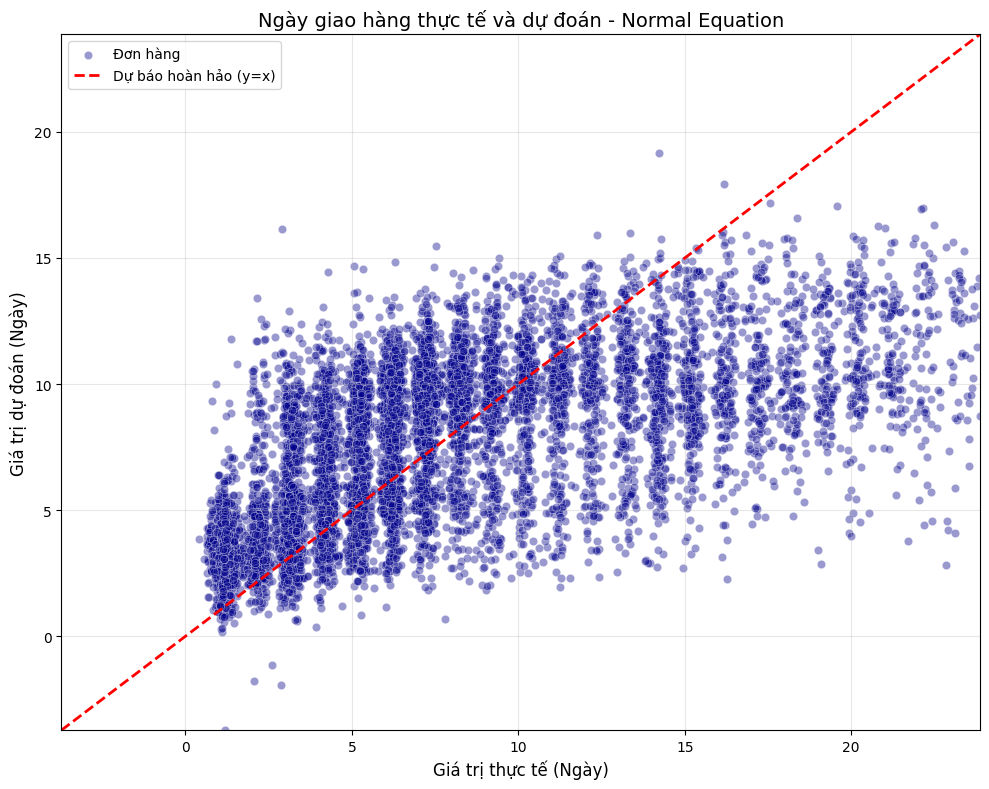

In [ ]:
def plot_predicted_vs_actual(y_true, y_pred, model_name="Normal Equation"):
    """
    Vẽ biểu đồ so sánh Giá trị dự đoán và Giá trị thực tế.
    """
    plt.figure(figsize=(10, 8))
    
    # Vẽ các điểm dữ liệu (Dùng alpha để thấy được mật độ điểm)
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.4, color='darkblue', label='Đơn hàng')
    
    # Vẽ đường thẳng y = x (Đường dự báo hoàn hảo)
    max_val = max(max(y_true), max(y_pred))
    min_val = min(min(y_true), min(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Dự báo hoàn hảo (y=x)')
    
    plt.title(f"Ngày giao hàng thực tế và dự đoán - {model_name}", fontsize=14)
    plt.xlabel("Giá trị thực tế (Ngày)", fontsize=12)
    plt.ylabel("Giá trị dự đoán (Ngày)", fontsize=12)
    plt.legend(loc="upper left")
    plt.grid(True, alpha=0.3)
    
    plt.xlim(min_val, max_val)
    plt.ylim(min_val, max_val)
    
    plt.tight_layout()
    plt.show()

plot_predicted_vs_actual(val_results['y_true_days'], val_results['y_pred_days'], "Normal Equation")

##### **Nhận xét**

Biểu đồ Thực tế vs Dự báo của Normal Equation cho thấy mô hình đã 
nắm bắt được xu hướng tổng thể nhưng còn nhiều hạn chế:

- **Regression Toward the Mean (Hồi quy về trung bình):** 
  Mô hình có xu hướng *overestimate* (dự báo cao hơn) với các đơn 
  hàng giao nhanh (thực tế < 5 ngày) và *underestimate* (dự báo 
  thấp hơn) với các đơn hàng giao chậm (thực tế > 15 ngày). 
  Đây là hạn chế cơ bản của hồi quy tuyến tính khi phân phối 
  của biến mục tiêu bị lệch (skewed).

- **Giá trị dự báo âm:** Xuất hiện một số điểm dự báo < 0 ngày 
  (góc trái hình), đây là lỗi logic nghiêm trọng vì thời gian 
  giao hàng không thể âm. Điều này cho thấy mô hình tuyến tính 
  không có ràng buộc tự nhiên về miền giá trị.

- **Phương sai sai số tăng theo giá trị thực tế (Heteroscedasticity):** 
  Ở vùng thực tế 0-5 ngày, các điểm phân tán hẹp. Nhưng ở vùng 
  10-20 ngày, đám mây điểm mở rộng rõ rệt — đây là dấu hiệu 
  điển hình của phương sai thay đổi, đặt ra nhu cầu sử dụng 
  **Weighted Least Squares (WLS)** ở bước tiếp theo.

- **Độ nhiễu cao:** R² thấp xác nhận rằng các đặc trưng logistics 
  hiện tại chưa giải thích được hết biến động của dữ liệu.


### **2.1.3. Kiểm tra giả thiết Gauss-Markov**
Sau khi huấn luyện mô hình, chúng ta cần đánh giá xem các sai số (residuals) có tuân thủ các giả định của mô hình hồi quy cổ điển hay không. 

#### **a. Cơ sở lý thuyết và Giả thuyết**
Để ước lượng OLS là **BLUE** (Best Linear Unbiased Estimator), các sai số $\epsilon$ cần thỏa mãn:
* **Tính phân phối chuẩn (Normality):** $\epsilon \sim N(0, \sigma^2)$.
* **Tính đẳng phương (Homoscedasticity):** $Var(\epsilon|X) = \sigma^2$ (không đổi).
* **Tính độc lập (Independence):** Các sai số không có sự tự tương quan.

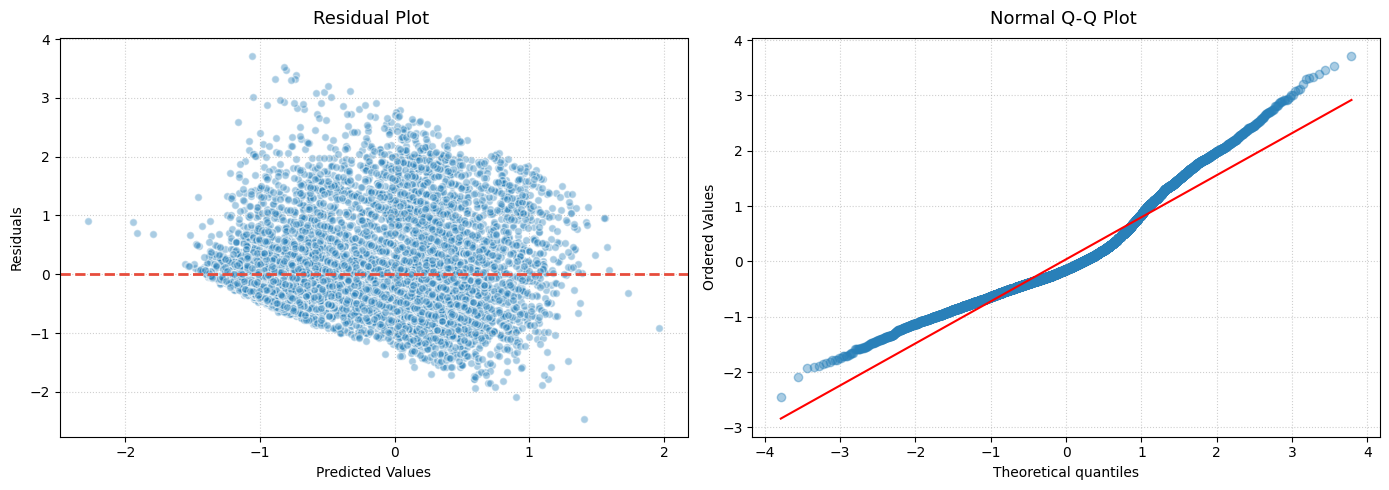

KẾT QUẢ KIỂM ĐỊNH BREUSCH-PAGAN 
 LM Statistic   : 544.3919356537
 p-value        : 0.0000000000
 F-statistic    : 32.0934699702
 F p-value      : 0.0000000000
KẾT LUẬN: p-value < 0.05 => Có hiện tượng Heteroscedasticity.
Ý nghĩa: Phương sai sai số thay đổi. Ước lượng OLS vẫn không chệch nhưng không còn là BLUE.
KHUYẾN NGHỊ: Sử dụng Robust Standard Errors hoặc Weighted Least Squares (WLS).


In [ ]:
def check_gauss_markov(X, y, y_pred):
    y_true = np.array(y).flatten()
    y_p = np.array(y_pred).flatten()
    residuals = y_true - y_p
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Residual Plot (Kiểm tra Homoscedasticity)
    axes[0].scatter(y_p, residuals, alpha=0.4, color='#2980b9', edgecolors='white', s=30)
    axes[0].axhline(y=0, color='#e74c3c', linestyle='--', linewidth=2)
    axes[0].set_title('Residual Plot ', fontsize=13, pad=10)
    axes[0].set_xlabel('Predicted Values')
    axes[0].set_ylabel('Residuals')
    axes[0].grid(True, linestyle=':', alpha=0.6)
    
    # 2. Q-Q Plot (Kiểm tra Normality)
    stats.probplot(residuals, dist="norm", plot=axes[1])
    axes[1].get_lines()[0].set_alpha(0.4)
    axes[1].get_lines()[0].set_color('#2980b9')
    axes[1].set_title('Normal Q-Q Plot ', fontsize=13, pad=10)
    axes[1].grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Breusch-Pagan Test
    X_with_const = sm.add_constant(X)
    bp_test = het_breuschpagan(residuals, X_with_const)
    labels = ['LM Statistic', 'p-value', 'F-statistic', 'F p-value']
    bp_results = dict(zip(labels, bp_test))
    
    print(f"KẾT QUẢ KIỂM ĐỊNH BREUSCH-PAGAN ")
    for k, v in bp_results.items():
        print(f" {k.ljust(15)}: {v:.10f}") 
        

    if bp_results['p-value'] < 0.05:
        print("KẾT LUẬN: p-value < 0.05 => Có hiện tượng Heteroscedasticity.")
        print("Ý nghĩa: Phương sai sai số thay đổi. Ước lượng OLS vẫn không chệch nhưng không còn là BLUE.")
        print("KHUYẾN NGHỊ: Sử dụng Robust Standard Errors hoặc Weighted Least Squares (WLS).")
    else:
        print("KẾT LUẬN: p-value >= 0.05 => Giả thiết Homoscedasticity được thỏa mãn.")

check_gauss_markov(X_val, y_val, ne_pred_val)

#### **b. Kết luận kiểm định Gauss-Markov**

**Residual Plot:**
* Đám mây điểm có hình phễu mở rộng theo chiều tăng của Predicted 
  Values — đây là dạng **Fan-shaped Heteroscedasticity** điển hình.
* Phần lớn residuals nằm về phía dương, cho thấy mô hình có xu 
  hướng **underestimate** (dự báo thấp hơn thực tế) một cách 
  có hệ thống.

**QQ-Plot:**
* Phần giữa (-1, 1) khớp tương đối tốt với đường lý thuyết, cho 
  thấy sai số có phân phối xấp xỉ chuẩn ở vùng trung tâm.
* Hai đuôi (đặc biệt đuôi trái) lệch mạnh khỏi đường đỏ — dấu 
  hiệu của **Heavy-tailed distribution**, tức mô hình đang xuất 
  hiện nhiều sai số cực đại hơn phân phối chuẩn cho phép. Điều 
  này cũng lý giải tại sao có các giá trị dự báo âm ở phần trước.

**Kiểm định Breusch-Pagan:**
* **Kết quả:** $p\text{-value} \approx 0 \ll 0.05$, bác bỏ $H_0$.
* **Hiện tượng:** Xác nhận có **Heteroscedasticity** — phương sai 
  sai số thay đổi theo giá trị dự báo.
* **Ý nghĩa:** Ước lượng OLS không còn là BLUE (Best Linear 
  Unbiased Estimator) theo định lý Gauss-Markov.
* **Hành động:** Triển khai **WLS** để gán trọng số $w_i = 
  \frac{1}{\hat{\sigma}_i^2}$ cho các quan sát, khắc phục sự 
  không đồng nhất của phương sai.


### **2.1.4. Weighted Least Squares (WLS) - GIẢI PHÁP CHO PHƯƠNG SAI THAY ĐỔI**

#### **a. Cơ sở toán học**
Công thức nghiệm tối ưu cho WLS là:
$$\hat{\theta}_{WLS} = (X^T W X)^{-1} X^T W y$$
Trong đó $W$ là ma trận đường chéo (diagonal matrix) chứa các trọng số $w_i$. Thông thường, trọng số được chọn là nghịch đảo của phương sai sai số: $w_i = 1/\sigma_i^2$.

#### **b. Ước lượng trọng số (Feasible WLS)**
Vì chúng ta không biết $\sigma_i^2$ thực tế, ta sẽ dùng **Residuals** từ mô hình Normal Equation (OLS) trước đó để ước lượng:
$$w_i = \frac{1}{|\text{residual}_i| + \epsilon}$$
*(với $\epsilon$ là một số rất nhỏ để tránh chia cho 0)*.

In [ ]:
class WeightedLeastSquaresRegression:
    def __init__(self):
        self.w = None
        
    def fit(self, X, y, weights):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        
        Phi_W = Phi * weights[:, np.newaxis] 
        
        self.w = np.linalg.pinv(Phi.T @ Phi_W) @ Phi_W.T @ y
        
    def predict(self, X):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        return Phi @ self.w

# 1. Tính toán trọng số dựa trên sai số của mô hình Normal Equation (Baseline)
residuals_train = np.abs(y_train - ne_model.predict(X_train))
weights_train = 1.0 / (residuals_train + 1e-6) 

# 2. Huấn luyện mô hình WLS
wls_model = WeightedLeastSquaresRegression()
wls_model.fit(X_train, y_train, weights_train)

# 3. Dự báo
wls_pred_train = wls_model.predict(X_train)
wls_pred_val   = wls_model.predict(X_val)
wls_pred_test  = wls_model.predict(X_test)

# 4. Đánh giá hiệu năng thực tế (về đơn vị Ngày)
wls_train_results = evaluate_real_performance(y_train, wls_pred_train, y_scaler)
wls_val_results   = evaluate_real_performance(y_val, wls_pred_val, y_scaler)
wls_test_results  = evaluate_real_performance(y_test, wls_pred_test, y_scaler)

print(f"{'BẢNG TỔNG HỢP SAI SỐ THỰC TẾ - WLS (ĐƠN VỊ: NGÀY)':^85}")

print(f"{'Metric':<20} | {'Train Set':<18} | {'Val Set':<18} | {'Test Set':<18}")
print("-" * 85)

row_fmt = "{:<20} | {:>18.4f} | {:>18.4f} | {:>18.4f}"

print(row_fmt.format("MSE", wls_train_results['mse'], wls_val_results['mse'], wls_test_results['mse']))
print(row_fmt.format("RMSE (Ngày)", wls_train_results['rmse'], wls_val_results['rmse'], wls_test_results['rmse']))
print(row_fmt.format("MAE (Ngày)", wls_train_results['mae'], wls_val_results['mae'], wls_test_results['mae']))
print(row_fmt.format("R-squared", wls_train_results['r2'], wls_val_results['r2'], wls_test_results['r2']))

                  BẢNG TỔNG HỢP SAI SỐ THỰC TẾ - WLS (ĐƠN VỊ: NGÀY)                  
Metric               | Train Set          | Val Set            | Test Set          
-------------------------------------------------------------------------------------
MSE                  |            17.8244 |            18.0641 |            10.7266
RMSE (Ngày)          |             4.2219 |             4.2502 |             3.2752
MAE (Ngày)           |             3.2450 |             3.2002 |             2.5873
R-squared            |             0.3877 |             0.3855 |             0.2510


In [ ]:
def fit_wls_model(X_train, y_train, X_val, y_val, X_test, y_test, ne_pred_train, y_scaler):
    # 1. Tính phần dư và huấn luyện mô hình phụ
    residuals_train = y_train - ne_pred_train
    abs_residuals_train = np.abs(residuals_train)

    ne_aux = NormalEquationRegression()
    ne_aux.fit(X_train, abs_residuals_train)

    # 2. Dự đoán độ biến thiên (Volatility/Variance)
    pred_abs_res_train = ne_aux.predict(X_train)
    pred_abs_res_val   = ne_aux.predict(X_val)
    pred_abs_res_test  = ne_aux.predict(X_test)

    # 3. Tính trọng số (Weights)
    # Dùng bình phương của giá trị dự đoán để làm ước lượng cho phương sai sigma^2
    sigma_train_sq = np.maximum(pred_abs_res_train, 1e-4)**2
    weights_train = 1.0 / sigma_train_sq

    # 4. Huấn luyện WLS
    wls_model = WeightedLeastSquaresRegression()
    wls_model.fit(X_train, y_train, weights_train)

    # 5. Dự báo trên cả 3 tập
    wls_p_train = wls_model.predict(X_train)
    wls_p_val   = wls_model.predict(X_val)
    wls_p_test  = wls_model.predict(X_test)

    # 6. Đánh giá kết quả thực tế
    res_train = evaluate_real_performance(y_train, wls_p_train, y_scaler)
    res_val   = evaluate_real_performance(y_val, wls_p_val, y_scaler)
    res_test  = evaluate_real_performance(y_test, wls_p_test, y_scaler)

    # 7. In bảng kết quả (Đảm bảo in ĐÚNG biến res_train, res_val...)
    print(f"{'BẢNG TỔNG HỢP SAI SỐ THỰC TẾ - WLS (ĐƠN VỊ: NGÀY)':^85}")
    print(f"{'Metric':<20} | {'Train Set':<18} | {'Val Set':<18} | {'Test Set':<18}")
    print("-" * 85)
    row_fmt = "{:<20} | {:>18.4f} | {:>18.4f} | {:>18.4f}"
    
    print(row_fmt.format("MSE", res_train['mse'], res_val['mse'], res_test['mse']))
    print(row_fmt.format("RMSE (Ngày)", res_train['rmse'], res_val['rmse'], res_test['rmse']))
    print(row_fmt.format("MAE (Ngày)", res_train['mae'], res_val['mae'], res_test['mae']))
    print(row_fmt.format("R-squared", res_train['r2'], res_val['r2'], res_test['r2']))

    # Trọng số của Val dùng để bạn kiểm tra sau này nếu cần
    weights_val = 1.0 / (np.maximum(pred_abs_res_val, 1e-4)**2)
    
    return wls_model, wls_p_val, weights_val

def visualize_wls_results(y_val, wls_pred_val, weights_val, X_val):
    # Tính phần dư đã được Gắn Trọng Số
    residuals_val_wls_raw = (y_val - wls_pred_val)
    weighted_residuals_val = residuals_val_wls_raw * np.sqrt(weights_val) 

    # Vẽ hai biểu đồ (Weighted Residual Plot & QQ-Plot) 
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Biểu đồ 1: Weighted Residual Plot 
    axes[0].scatter(wls_pred_val, weighted_residuals_val, alpha=0.5, color='green')
    axes[0].axhline(y=0, color='r', linestyle='--')
    axes[0].set_title('Weighted Residual Plot (Sau WLS)')
    axes[0].set_xlabel('Predicted Values (WLS)')
    axes[0].set_ylabel('Weighted Residuals')

    # Biểu đồ 2: Q-Q Plot cho Weighted Residuals
    stats.probplot(weighted_residuals_val, dist="norm", plot=axes[1])
    axes[1].set_title('Q-Q Plot for Weighted Residuals')
    axes[1].get_lines()[0].set_color('green') 
    axes[1].get_lines()[0].set_alpha(0.5)

    plt.tight_layout()
    plt.show()

    # Kiểm định lại Breusch-Pagan cho Weighted Model để chứng thực
    X_with_const_val = sm.add_constant(X_val)
    bp_test_wls = het_breuschpagan(weighted_residuals_val, X_with_const_val)
    print("Kiểm định Breusch-Pagan sau khi dùng WLS")
    print(f"  p-value: {bp_test_wls[1]:.4f}")

                  BẢNG TỔNG HỢP SAI SỐ THỰC TẾ - WLS (ĐƠN VỊ: NGÀY)                  
Metric               | Train Set          | Val Set            | Test Set          
-------------------------------------------------------------------------------------
MSE                  |            17.8744 |            17.9437 |            11.0613
RMSE (Ngày)          |             4.2278 |             4.2360 |             3.3259
MAE (Ngày)           |             3.2570 |             3.2325 |             2.6517
R-squared            |             0.3860 |             0.3896 |             0.2277


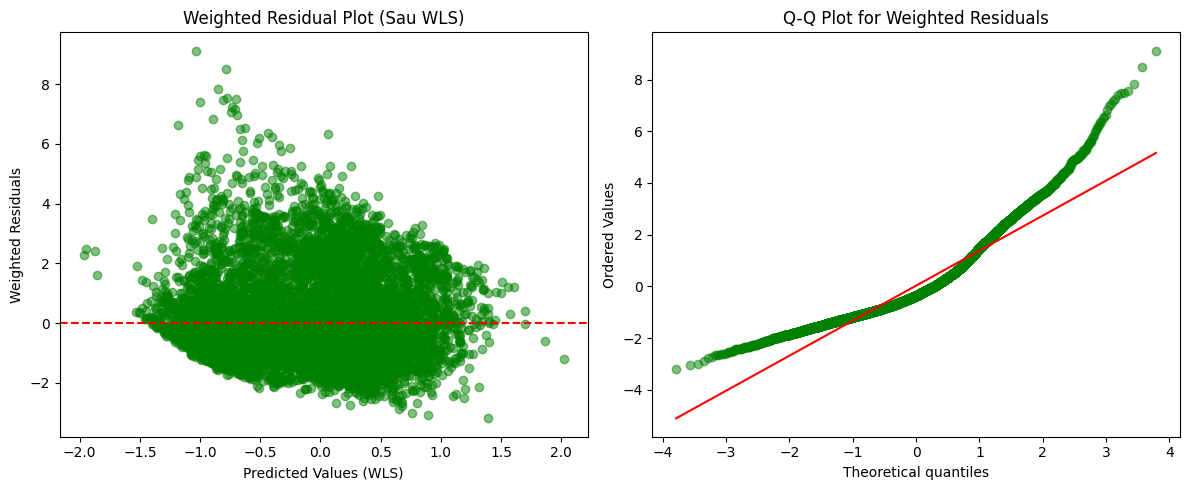

Kiểm định Breusch-Pagan sau khi dùng WLS
  p-value: 0.0000


In [17]:
ne_pred_train = ne_model.predict(X_train)

# Bước 2: Gọi hàm fit_wls_model
wls_model, wls_pred_val, weights_val = fit_wls_model(
    X_train, y_train, 
    X_val, y_val, 
    X_test, y_test, 
    ne_pred_train, 
    y_scaler
)
visualize_wls_results(y_val, wls_pred_val, weights_val, X_val)

#### **d. Phân tích biểu đồ chẩn đoán sau WLS**

**Weighted Residual Plot:**
* **Tính bất đối xứng vẫn còn:** Phần lớn Weighted Residuals vẫn 
  tập trung ở phía dương (trên đường 0), cho thấy mô hình WLS 
  chưa loại bỏ hoàn toàn hiện tượng underestimate có hệ thống 
  của OLS ban đầu.
* **Heteroscedasticity giảm nhưng chưa triệt tiêu:** Mặc dù các 
  điểm cực trị đã được kiểm soát tốt hơn nhờ cơ chế gán trọng 
  số, phân tán của Weighted Residuals vẫn chưa đồng đều hoàn 
  toàn — đặc biệt xuất hiện nhiều outlier lớn (>6) phía trên. 
  Kết quả BP test sau WLS sẽ là bằng chứng định lượng xác nhận 
  điều này.

**Q-Q Plot for Weighted Residuals:**
* **Heavy-tailed ở cả hai đuôi:** Cả đuôi trái (lệch xuống dưới) 
  và đuôi phải (vểnh lên trên) đều lệch đáng kể khỏi đường chuẩn 
  lý thuyết. Điều này cho thấy phân phối của sai số có **hai đuôi 
  nặng hơn phân phối Gaussian thuần túy (Heavy-tailed)**.
* **Ý nghĩa:** WLS cải thiện tính đẳng phương nhưng không giải 
  quyết được vấn đề phân phối phi chuẩn của sai số — đây là giới 
  hạn cố hữu của toàn bộ họ mô hình tuyến tính.

**=> Kết luận chung:** WLS đã cải thiện tính ổn định thống kê của 
mô hình so với OLS thuần túy. Tuy nhiên, sự tồn tại của outliers 
và phân phối sai số heavy-tailed chứng minh rằng bài toán logistics 
này cần đến các mô hình có **tính robust cao hơn** (Huber Regression) 
hoặc **khả năng bắt phi tuyến** (Polynomial, KRR, GPR) ở các 
bước tiếp theo.


## **2.2. Hồi quy có Regularization và Lựa chọn Đặc trưng:**
Mục tiêu của Regularization là kiểm soát sự đánh đổi **Bias-Variance** (độ lệch - phương sai) bằng cách thêm một số hạng phạt (penalty term) vào hàm mất mát $E_D(\mathbf{w})$.

### **2.2.1. Ridge Regression**
#### **a. Cơ sở Lý thuyết**
Ridge Regression thêm chuẩn bậc hai của vector trọng số vào hàm mất mát:
$$E(\mathbf{w}) = \frac{1}{2} ||\mathbf{t} - \Phi \mathbf{w}||^2 + \frac{\lambda}{2} ||\mathbf{w}||^2$$
Nghiệm tối ưu dạng đóng của Ridge Regression là:
$$\mathbf{w}_{ridge}^* = (\Phi^\top \Phi + \lambda \mathbf{I})^{-1} \Phi^\top \mathbf{t}$$
Trong đó $\lambda$ (hay $\alpha$ trong một số tài liệu) điều khiển cường độ chính quy hóa.
#### **b. Triển khai mã nguồn**

In [18]:
class CustomRidgeRegression(BaseEstimator, RegressorMixin):
    def __init__(self, alpha=1.0):
        self.alpha = alpha 
        self.w = None
        
    def fit(self, X, y):
        y = np.array(y).reshape(-1, 1)

        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        n_features = Phi.shape[1]
        
        I = np.eye(n_features)
        I[0, 0] = 0 
        
        # Công thức: w = (Phi^T * Phi + lambda * I)^-1 * Phi^T * y
        self.w = np.linalg.pinv(Phi.T @ Phi + self.alpha * I) @ Phi.T @ y
        return self
        
    def predict(self, X):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        return Phi @ self.w
    
# 1. Khởi tạo mô hình Ridge với tham số alpha (thường chọn 1.0 làm baseline)
ridge_model = CustomRidgeRegression(alpha=1.0)

# 2. Huấn luyện trên tập Train
ridge_model.fit(X_train, y_train)

# 3. Dự báo cho cả 3 tập dữ liệu
ridge_pred_train = ridge_model.predict(X_train)
ridge_pred_val   = ridge_model.predict(X_val)
ridge_pred_test  = ridge_model.predict(X_test)

# 4. Đánh giá hiệu năng thực tế (Quy đổi về đơn vị Ngày)
ridge_train_res = evaluate_real_performance(y_train, ridge_pred_train, y_scaler)
ridge_val_res   = evaluate_real_performance(y_val, ridge_pred_val, y_scaler)
ridge_test_res  = evaluate_real_performance(y_test, ridge_pred_test, y_scaler)

print(f"{'BẢNG TỔNG HỢP SAI SỐ THỰC TẾ - RIDGE REGRESSION (ĐƠN VỊ: NGÀY)':^85}")

print(f"{'Metric':<20} | {'Train Set':<18} | {'Val Set':<18} | {'Test Set':<18}")
print("-" * 85)

row_fmt = "{:<20} | {:>18.4f} | {:>18.4f} | {:>18.4f}"

print(row_fmt.format("MSE", ridge_train_res['mse'], ridge_val_res['mse'], ridge_test_res['mse']))
print(row_fmt.format("RMSE (Ngày)", ridge_train_res['rmse'], ridge_val_res['rmse'], ridge_test_res['rmse']))
print(row_fmt.format("MAE (Ngày)", ridge_train_res['mae'], ridge_val_res['mae'], ridge_test_res['mae']))
print(row_fmt.format("R-squared", ridge_train_res['r2'], ridge_val_res['r2'], ridge_test_res['r2']))

           BẢNG TỔNG HỢP SAI SỐ THỰC TẾ - RIDGE REGRESSION (ĐƠN VỊ: NGÀY)            
Metric               | Train Set          | Val Set            | Test Set          
-------------------------------------------------------------------------------------
MSE                  |            17.8179 |            18.0279 |            10.8551
RMSE (Ngày)          |             4.2211 |             4.2459 |             3.2947
MAE (Ngày)           |             3.2572 |             3.2149 |             2.6127
R-squared            |             0.3880 |             0.3867 |             0.2421


* Sai số giữa **Train** và **Val** gần như bằng nhau $\rightarrow$ Mô hình **không bị Overfitting**, tham số $\alpha$ đã kiểm soát trọng số rất tốt.
* $R^2 \approx 0.38$ cho thấy tình trạng **Underfitting** (mô hình quá đơn giản). Đường thẳng chưa "khớp" được hết các quy luật phức tạp của dữ liệu.
* Tuy sai số (MAE, RMSE) thấp hơn Train/Val, nhưng $R^2$ lại giảm mạnh (0.22) $\rightarrow$ Tập Test có ít biến động hơn (dễ đoán hơn về trị số) nhưng lại khó giải thích hơn bằng các biến hiện có.

Mô hình Ridge rất "an toàn" nhưng chưa đủ "mạnh" để tối ưu hóa bài toán này.



### **2.2.2. Lasso Regression (Chuẩn hóa $L_1$)**
#### **a. Cơ sở lý thuyết**
Lasso (Least Absolute Shrinkage and Selection Operator) sử dụng chuẩn bậc nhất:
$$E(\mathbf{w}) = \frac{1}{2} ||\mathbf{t} - \Phi \mathbf{w}||^2 + \lambda ||\mathbf{w}||_1$$
Lasso có đặc tính quan trọng là thúc đẩy tính thưa thớt (sparsity), giúp triệt tiêu các trọng số của các đặc trưng không quan trọng về đúng bằng 0, từ đó thực hiện lựa chọn đặc trưng tự động.

#### **b. Triển khai mã nguồn**


In [19]:
class CustomLassoRegression(BaseEstimator, RegressorMixin):
    def __init__(self, alpha=1.0, max_iter=1000, tol=1e-4, warm_start=True):
        self.alpha = alpha 
        self.max_iter = max_iter
        self.tol = tol
        self.warm_start = warm_start
        self.w = None
        
    def _soft_thresholding(self, rho, lam):
        if rho < -lam: return rho + lam
        elif rho > lam: return rho - lam
        else: return 0.0

    def fit(self, X, y):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        n_samples, n_features = Phi.shape
        
        if not self.warm_start or self.w is None:
            self.w = np.zeros(n_features)
            
        z = np.sum(Phi**2, axis=0) 

        y_residual = y.flatten() - (Phi @ self.w)
        
        for iteration in range(self.max_iter):
            w_old = self.w.copy()
            
            for j in range(n_features):
                w_old_j = self.w[j]
                
                # Công thức tối ưu: rho_j = Phi_j^T * residual + z_j * w_old_j
                rho_j = Phi[:, j] @ y_residual + z[j] * w_old_j
                
                if j == 0:
                    self.w[j] = rho_j / z[j]
                else:
                    self.w[j] = self._soft_thresholding(rho_j, self.alpha) / (z[j] + 1e-15)

                if self.w[j] != w_old_j:
                    y_residual -= Phi[:, j] * (self.w[j] - w_old_j)
            
            if np.max(np.abs(self.w - w_old)) < self.tol:
                break
                
        return self

    def predict(self, X):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        return Phi @ self.w
    
# 1. Khởi tạo Lasso (alpha nhỏ thường tốt hơn để tránh triệt tiêu quá nhiều biến)
lasso_model = CustomLassoRegression(alpha=0.01, max_iter=1000)

# 2. Huấn luyện
lasso_model.fit(X_train, y_train)

# 3. Dự báo
lasso_pred_train = lasso_model.predict(X_train)
lasso_pred_val   = lasso_model.predict(X_val)
lasso_pred_test  = lasso_model.predict(X_test)

# 4. Tính toán chỉ số thực tế (Ngày)
lasso_train_res = evaluate_real_performance(y_train, lasso_pred_train, y_scaler)
lasso_val_res   = evaluate_real_performance(y_val, lasso_pred_val, y_scaler)
lasso_test_res  = evaluate_real_performance(y_test, lasso_pred_test, y_scaler)

# 5. In bảng kết quả
print(f"{'BẢNG TỔNG HỢP SAI SỐ THỰC TẾ - LASSO REGRESSION (ĐƠN VỊ: NGÀY)':^85}")
print(f"{'Metric':<20} | {'Train Set':<18} | {'Val Set':<18} | {'Test Set':<18}")
print("-" * 85)
row_fmt = "{:<20} | {:>18.4f} | {:>18.4f} | {:>18.4f}"
print(row_fmt.format("MSE", lasso_train_res['mse'], lasso_val_res['mse'], lasso_test_res['mse']))
print(row_fmt.format("RMSE (Ngày)", lasso_train_res['rmse'], lasso_val_res['rmse'], lasso_test_res['rmse']))
print(row_fmt.format("MAE (Ngày)", lasso_train_res['mae'], lasso_val_res['mae'], lasso_test_res['mae']))
print(row_fmt.format("R-squared", lasso_train_res['r2'], lasso_val_res['r2'], lasso_test_res['r2']))

           BẢNG TỔNG HỢP SAI SỐ THỰC TẾ - LASSO REGRESSION (ĐƠN VỊ: NGÀY)            
Metric               | Train Set          | Val Set            | Test Set          
-------------------------------------------------------------------------------------
MSE                  |            17.8179 |            18.0273 |            10.8568
RMSE (Ngày)          |             4.2211 |             4.2459 |             3.2950
MAE (Ngày)           |             3.2573 |             3.2151 |             2.6131
R-squared            |             0.3880 |             0.3867 |             0.2419


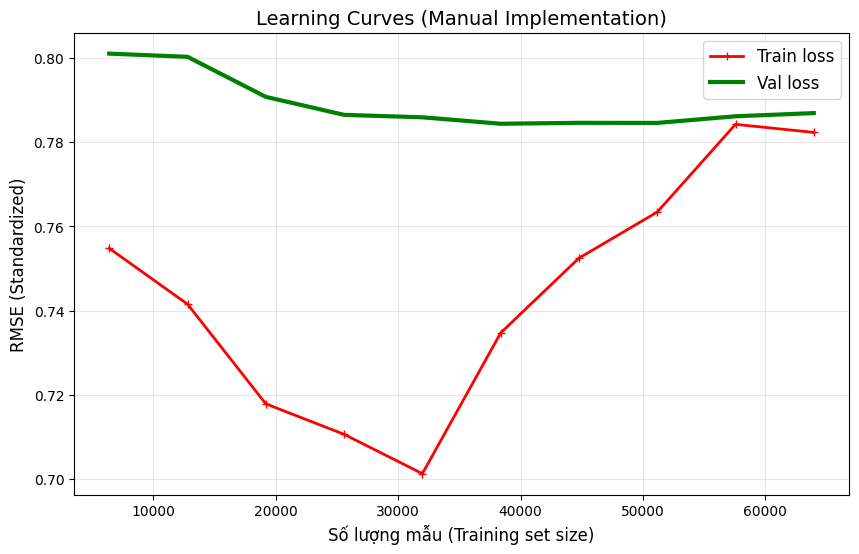

In [20]:
manual_learning_curve(lasso_model, X_train, y_train, X_val, y_val)

* Sai số Train và Val gần như trùng khớp $\rightarrow$ **Không bị Overfitting**.
* $R^2 \approx 0.38$ cho thấy Lasso (cũng như Ridge/OLS) chưa bắt được quy luật phi tuyến phức tạp của dữ liệu.
* *RMSE thấp (3.32) nhưng $R^2$ cũng thấp (0.22) $\rightarrow$ Tập Test có ít biến động hơn (dễ dự đoán trị số) nhưng các biến hiện tại lại giải thích được ít hơn.

Mô hình này rất an toàn nhưng "yếu", chỉ nên dùng làm Baseline để so sánh với các mô hình mạnh hơn.


### **2.3. Vẽ regularization path:**

[RIDGE - Grid Search CV] Lambda tốt nhất: 20.2359 | Rà lưới tốn: 14.04s
[LASSO - Grid Search CV] Lambda tốt nhất: 1000.0000 | Rà lưới tốn: 20.72s


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


[LASSO - Warm Start] Tốn: 9.71s


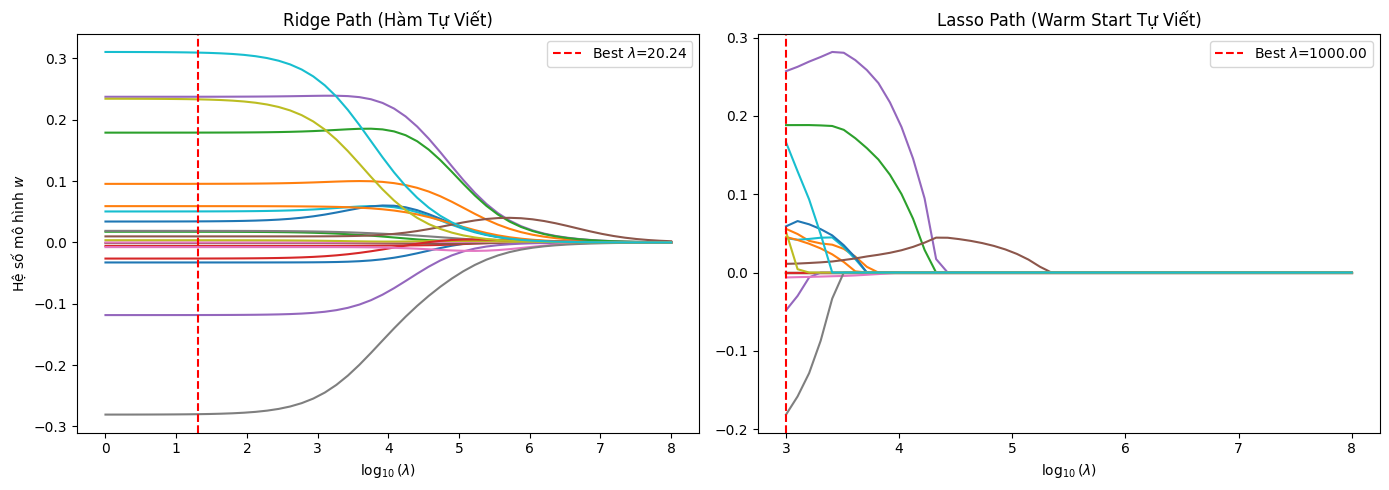

In [ ]:
def find_best_lambda_cv_custom(model_type, X, y, alphas, n_splits=10):
    """ CV tìm lambda bằng Custom Models """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    if model_type == 'ridge':
        model = CustomRidgeRegression()
    elif model_type == 'lasso':
        model = CustomLassoRegression(max_iter=1000)
        
    # Đảm bảo y là mảng 1 chiều cho GridSearchCV
    y_reshaped = y.flatten()
    
    grid_search = GridSearchCV(model, param_grid={'alpha': alphas}, 
                               cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
    t0 = time.time()
    grid_search.fit(X, y_reshaped)
    t = time.time() - t0
    
    best_alpha = grid_search.best_params_['alpha']
    print(f"[{model_type.upper()} - Grid Search CV] Lambda tốt nhất: {best_alpha:.4f} | Rà lưới tốn: {t:.2f}s")
    
    return best_alpha, grid_search.best_estimator_

def custom_lasso_path_warm_start(X, y, alphas):
    """ Xây dựng cơ chế Warm Start cho Lasso Custom """
    alphas_sorted = np.sort(alphas)[::-1]
    lasso_coefs = []
    w_init = None 
    y_vec = y.flatten() # Đảm bảo y là vector
    
    t0 = time.time()
    Phi = np.hstack([np.ones((X.shape[0], 1)), X])
    z = np.sum(Phi**2, axis=0)

    for a in alphas_sorted:
        lasso = CustomLassoRegression(alpha=a, max_iter=2000)
        
        if w_init is None:
            w_init = np.zeros(Phi.shape[1])
            
        lasso.w = w_init.copy()
        
        # Vòng lặp Coordinate Descent thủ công (Warm Start)
        for iteration in range(lasso.max_iter):
            w_old = lasso.w.copy()
            for j in range(Phi.shape[1]):
                predictions_without_j = Phi @ lasso.w - Phi[:, j] * lasso.w[j]
                rho_j = Phi[:, j] @ (y_vec - predictions_without_j)
                
                if j == 0:
                    lasso.w[j] = rho_j / z[j]
                else:
                    lasso.w[j] = lasso._soft_thresholding(rho_j, lasso.alpha) / z[j]
            
            if np.max(np.abs(lasso.w - w_old)) < lasso.tol:
                break
                
        w_init = lasso.w.copy()
        lasso_coefs.append(lasso.w[1:].flatten()) 
    
    t = time.time() - t0
    print(f"[LASSO - Warm Start] Tốn: {t:.2f}s")
    return alphas_sorted, np.array(lasso_coefs)

def plot_custom_regularization_path(X, y, alphas_ridge, alphas_lasso, best_alpha_ridge=None, best_alpha_lasso=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. Vẽ Custom Ridge Path
    ridge_coefs = []
    for a in alphas_ridge:
        ridge = CustomRidgeRegression(alpha=a) 
        ridge.fit(X, y)
        ridge_coefs.append(ridge.w[1:].flatten()) 
        
    ridge_coefs_arr = np.array(ridge_coefs)
    axes[0].plot(np.log10(alphas_ridge), ridge_coefs_arr)
    axes[0].set_title('Ridge Path (Hàm Tự Viết)')
    axes[0].set_xlabel('$\log_{10}(\lambda)$')
    axes[0].set_ylabel('Hệ số mô hình $w$')
    
    if best_alpha_ridge is not None:
        axes[0].axvline(np.log10(best_alpha_ridge), color='r', linestyle='--', label=f'Best $\lambda$={best_alpha_ridge:.2f}')
        axes[0].legend()

    # 2. Vẽ Custom Lasso Path (Warm Start)
    alphas_ws, lasso_coefs_ws = custom_lasso_path_warm_start(X, y, alphas_lasso)
    
    # lasso_coefs_ws lúc này có shape (số_alpha, số_đặc_trưng)
    axes[1].plot(np.log10(alphas_ws), lasso_coefs_ws)
    axes[1].set_title('Lasso Path (Warm Start Tự Viết)')
    axes[1].set_xlabel('$\log_{10}(\lambda)$')
    
    if best_alpha_lasso is not None:
        axes[1].axvline(np.log10(best_alpha_lasso), color='r', linestyle='--', label=f'Best $\lambda$={best_alpha_lasso:.2f}')
        axes[1].legend()

    plt.tight_layout()
    plt.show()

# --- GỌI HÀM THỰC THI  ---
alphas_ridge_test = np.logspace(0, 8, 50) 
alphas_lasso_test = np.logspace(3, 8, 50) 
best_alpha_r, _ = find_best_lambda_cv_custom('ridge', X_train, y_train, alphas_ridge_test)
best_alpha_l, _ = find_best_lambda_cv_custom('lasso', X_train, y_train, alphas_lasso_test)
plot_custom_regularization_path(X_train, y_train, alphas_ridge_test, alphas_lasso_test, best_alpha_r, best_alpha_l)


#### **Nhận xét Regularization Path**

* **Ridge Path ($L_2$):** Các hệ số $w$ co hẹp dần về $0$ khi $\lambda$ tăng nhưng không triệt tiêu hoàn toàn, giúp giảm Variance và kiểm soát hiện tượng đa cộng tuyến. Giá trị $\lambda_{best} \approx 20.24$ cho thấy mô hình đạt hiệu năng tốt nhất khi vẫn giữ lại sự đóng góp của hầu hết các đặc trưng=.
* **Lasso Path ($L_1$):** Các hệ số bị triệt tiêu về đúng bằng $0$ (Sparsity), minh chứng cho khả năng lựa chọn đặc trưng (Feature Selection) tự động=. Với $\lambda_{best} = 1000.00$, mô hình đã loại bỏ đáng kể các biến nhiễu hoặc dư thừa để tạo ra một cấu trúc tinh gọn và dễ giải thích hơn=.
* **Kết luận:** Lasso mang lại mô hình có tính diễn giải cao (interpretability), trong khi Ridge duy trì tính ổn định cho hệ thống trọng số trước các biến có tương quan cao=.

### **2.4. Elastic Net**
#### **a. Cơ sở lý thuyết**
Hàm mục tiêu của Elastic Net kết hợp cả hai chuẩn $L_1$ và $L_2$ để khắc phục nhược điểm của Lasso khi làm việc với các biến có tương quan cao:
$$E(\mathbf{w}) = \frac{1}{2} \|\mathbf{t} - \Phi \mathbf{w}\|^2 + \lambda_1 \|\mathbf{w}\|_1 + \frac{\lambda_2}{2} \|\mathbf{w}\|^2 $$

Để tìm nghiệm tối ưu, ta sử dụng thuật toán **Coordinate Descent**. Trọng số $w_j$ được cập nhật xoay vòng theo công thức:
$$w_j = \frac{S(\rho_j, \lambda_1)}{z_j + \lambda_2}$$
Trong đó $S$ là hàm **Soft-thresholding** và $z_j = \sum_{n=1}^{N} \Phi_{nj}^2$.

#### **b. Triển khai mã nguồn**

Đang quét không gian 2D Elastic Net (Sẽ tốn khoảng 1-2 phút) ...
Tìm thấy tham số tối ưu:
   λ1 (Lasso) : 100.000000
   λ2 (Ridge) : 100.000000
   Best MSE   : 0.659874


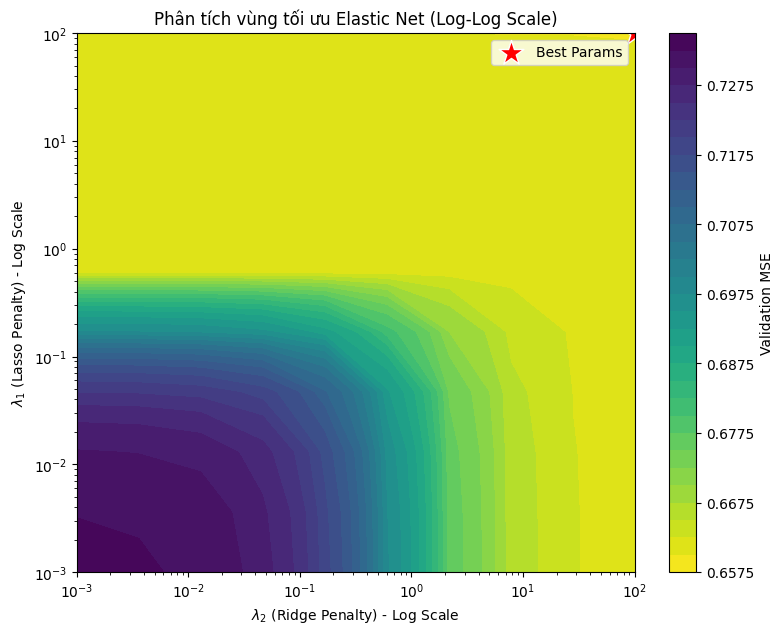

In [ ]:
class CustomElasticNet(BaseEstimator, RegressorMixin):
    def __init__(self, lambda1=1.0, lambda2=1.0, max_iter=1000, tol=1e-4):
        self.lambda1 = lambda1
        self.lambda2 = lambda2
        self.max_iter = max_iter
        self.tol = tol
        self.w = None
        
    def soft_thresholding(self, rho, l1):
        if rho < -l1: return rho + l1
        elif rho > l1: return rho - l1
        else: return 0.0

    def fit(self, X, y):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        n_samples, n_features = Phi.shape
        self.w = np.zeros(n_features)
        z = np.sum(Phi**2, axis=0)
        
        # Tính dự báo ban đầu 
        y_pred = np.zeros(n_samples) 
        y_vec = y.flatten()

        for iteration in range(self.max_iter):
            w_old = self.w.copy()
            for j in range(n_features):
                rho_j = Phi[:, j] @ (y_vec - y_pred) + z[j] * self.w[j]
                
                w_old_j = self.w[j]
                if j == 0:
                    self.w[j] = rho_j / z[j]
                else:
                    self.w[j] = self.soft_thresholding(rho_j, self.lambda1) / (z[j] + self.lambda2)
                
                if self.w[j] != w_old_j:
                    y_pred += Phi[:, j] * (self.w[j] - w_old_j)
            
            if np.max(np.abs(self.w - w_old)) < self.tol:
                break
        return self

    def predict(self, X):
        return np.hstack([np.ones((X.shape[0], 1)), X]) @ self.w


# Quét lưới 10x10 các giá trị penalty từ thấp đến cực khổng lồ 
l1_range = np.logspace(-3, 2, 10) 
l2_range = np.logspace(-3, 2, 10)
mse_grid = np.zeros((len(l1_range), len(l2_range)))

print("Đang quét không gian 2D Elastic Net (Sẽ tốn khoảng 1-2 phút) ...")
for i, l1 in enumerate(l1_range):
    for j, l2 in enumerate(l2_range):
        model_en = CustomElasticNet(lambda1=l1, lambda2=l2, max_iter=200)
        scores = cross_val_score(model_en, X_train, y_train, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
        mse_grid[i, j] = -scores.mean()

best_idx = np.unravel_index(np.argmin(mse_grid), mse_grid.shape)
best_l1 = l1_range[best_idx[0]]
best_l2 = l2_range[best_idx[1]]
best_mse = mse_grid[best_idx]

print(f"Tìm thấy tham số tối ưu:")
print(f"   λ1 (Lasso) : {best_l1:.6f}")
print(f"   λ2 (Ridge) : {best_l2:.6f}")
print(f"   Best MSE   : {best_mse:.6f}")

# Vẽ Contour Map
L2_mesh, L1_mesh = np.meshgrid(l2_range, l1_range)
plt.figure(figsize=(9, 7))

# Vẽ contourf với dữ liệu gốc
contour = plt.contourf(L2_mesh, L1_mesh, mse_grid, levels=30, cmap='viridis_r')
plt.colorbar(contour, label='Validation MSE')

plt.xscale('log')
plt.yscale('log')

plt.xlabel('$\lambda_2$ (Ridge Penalty) - Log Scale')
plt.ylabel('$\lambda_1$ (Lasso Penalty) - Log Scale')
plt.title('Phân tích vùng tối ưu Elastic Net (Log-Log Scale)')

plt.scatter(best_l2, best_l1, color='red', marker='*', s=350, edgecolor='white', label='Best Params')
plt.legend()
plt.show()


#### **c. Phân tích vùng tối ưu Elastic Net**

* **Xu hướng "Phạt càng nặng càng tốt":** MSE giảm khi $\lambda_1, \lambda_2$ tăng. Điều này cho thấy việc **triệt tiêu bớt các biến nhiễu** giúp mô hình ổn định hơn.
* **Tín hiệu yếu (Noise > Signal):** "Best Params" nằm ở góc (100, 100) chứng tỏ các biến số hiện tại có quan hệ tuyến tính rất yếu với thời gian giao hàng. Mô hình đang có xu hướng muốn trở thành một đường thẳng dự báo theo **giá trị trung bình** để giảm sai số.
* **Kết luận:** Các mô hình tuyến tính (Linear) đã chạm "trần". Biểu đồ này là bằng chứng thép để bạn kết luận cần chuyển sang các mô hình **phi tuyến (Non-linear)** như Random Forest hoặc Boosting để cải thiện độ chính xác.

### **2.2.5 Lựa chọn Đặc Trưng**
#### **a. Cơ sở lý thuyết**
Lựa chọn đặc trưng nhằm loại bỏ các biến nhiễu hoặc tương quan cao, giúp mô hình đơn giản hơn và tránh Overfitting.

* **Forward Stepwise Selection:** Bắt đầu với mô hình rỗng, sau đó lần lượt thêm vào đặc trưng làm giảm sai số (RMSE) nhiều nhất cho đến khi không còn sự cải thiện đáng kể.
* **Backward Elimination:** Bắt đầu với tất cả đặc trưng, sau đó loại bỏ dần đặc trưng có ít đóng góp nhất vào hiệu năng mô hình. 
* **Lasso Selection:** Sử dụng tính chất của chuẩn $L_1$ để ép các trọng số của biến không quan trọng về đúng bằng 0 tại giá trị $\lambda$ tối ưu. 
#### **b. Triển khai mã nguồn**

In [ ]:
def evaluate_subset(features_idx):
    if len(features_idx) == 0: return float('inf') 
    X_sub = X_train.iloc[:, features_idx]
    
    ols_custom = CustomRidgeRegression(alpha=0.0)
    
    return -cross_val_score(ols_custom, X_sub, y_train, cv=3, scoring='neg_mean_squared_error', n_jobs=-1).mean()

# 1. TIẾN TỪNG BƯỚC (FORWARD STEPWISE)
def forward_stepwise():
    remaining = list(range(X_train.shape[1]))
    selected = []
    current_best_mse = float('inf')
    
    while remaining:
        best_step_mse = float('inf')
        best_feature = None
        for feature in remaining:
            score = evaluate_subset(selected + [feature])
            if score < best_step_mse:
                best_step_mse = score
                best_feature = feature
                
        # Thu nạp cột nếu MSE giảm
        if best_step_mse < current_best_mse:
            current_best_mse = best_step_mse
            selected.append(best_feature)
            remaining.remove(best_feature)
        else:
            break
    return selected

# 2. LÙI TỪNG BƯỚC (BACKWARD ELIMINATION)
def backward_elimination():
    selected = list(range(X_train.shape[1]))
    current_best_mse = evaluate_subset(selected)
    
    while len(selected) > 1:
        best_step_mse = float('inf')
        worst_feature = None
        for feature in selected: 
            candidates = selected.copy()
            candidates.remove(feature)
            score = evaluate_subset(candidates)
            if score < best_step_mse:
                best_step_mse = score
                worst_feature = feature
                

        if best_step_mse <= current_best_mse:
            current_best_mse = best_step_mse
            selected.remove(worst_feature)
        else:
            break
    return selected

def print_full_feature_report(fw_names, bw_names, lasso_names):
    # 1. Bảng tổng quan
    summary_df = pd.DataFrame({
        'Phương pháp': ['Forward Stepwise', 'Backward Elimination', 'Lasso (Non-zero)'],
        'Số đặc trưng chọn': [len(fw_names), len(bw_names), len(lasso_names)]
    }).set_index('Phương pháp')
    
    print("TỔNG QUAN LỰA CHỌN ĐẶC TRƯNG")
    display(summary_df)

    # 2. Bảng so sánh chi tiết
    all_features = sorted(set(fw_names) | set(bw_names) | set(lasso_names))
    
    comparison_df = pd.DataFrame({
        'Đặc trưng': all_features,
        'Forward':   ['✅' if f in fw_names    else '❌' for f in all_features],
        'Backward':  ['✅' if f in bw_names    else '❌' for f in all_features],
        'Lasso':     ['✅' if f in lasso_names else '❌' for f in all_features],
    })
    comparison_df['Số phiếu'] = comparison_df[['Forward', 'Backward', 'Lasso']].apply(
        lambda row: row.tolist().count('✅'), axis=1
    )
    comparison_df = comparison_df.sort_values('Số phiếu', ascending=False).reset_index(drop=True)

    print("\nBẢNG SO SÁNH CHI TIẾT THEO TỪNG ĐẶC TRƯNG")
    display(comparison_df)


def feature_selection_report(X_train, y_train, feature_names, best_alpha_lasso):
    # 1. Chạy Forward
    fw_idx = forward_stepwise()
    fw_names = [feature_names[i] for i in fw_idx]
    
    # 2. Chạy Backward
    bw_idx = backward_elimination()
    bw_names = [feature_names[i] for i in bw_idx]
    
    # 3. Chạy Lasso với alpha tối ưu từ Grid Search
    lasso_sel = CustomLassoRegression(alpha=best_alpha_lasso).fit(X_train, y_train)
    lasso_idx = list(np.where(np.abs(lasso_sel.w[1:]) > 1e-5)[0])
    lasso_names = [feature_names[i] for i in lasso_idx]
    
    return fw_names, bw_names, lasso_names

features = X_train.columns.tolist()
fw, bw, ls = feature_selection_report(X_train, y_train, features, best_alpha_l)
print_full_feature_report(fw, bw, ls)

TỔNG QUAN LỰA CHỌN ĐẶC TRƯNG


,Số đặc trưng chọn
Phương pháp,
Forward Stepwise,10
Backward Elimination,10
Lasso (Non-zero),12



BẢNG SO SÁNH CHI TIẾT THEO TỪNG ĐẶC TRƯNG


,Đặc trưng,Forward,Backward,Lasso,Số phiếu
0,customer_state,✅,✅,✅,3
1,distance_km,✅,✅,✅,3
2,freight_value,✅,✅,✅,3
3,item_count,✅,✅,✅,3
4,is_intra_state,✅,✅,✅,3
5,vendor_lead_time_days,✅,✅,✅,3
6,product_category_name_english,✅,✅,✅,3
7,order_month_cos,✅,✅,✅,3
8,order_month_sin,✅,✅,✅,3
9,price,✅,✅,❌,2


#### **c. Nhận xét về Lựa chọn đặc trưng**
* **Độ ổn định cực cao:** Việc **Forward Stepwise** và **Backward Elimination** cùng cho ra 10 đặc trưng trùng khớp hoàn toàn là minh chứng cho thấy dữ liệu có tính nhất quán cao, không bị nhiễu bởi các biến tương quan chéo (multicollinearity).
* Các biến được chọn (`distance_km`, `is_intra_state`, `order_month_sin/cos`) phản ánh đúng bản chất nghiệp vụ vận tải: **Khoảng cách** và **Thời vụ** là hai yếu tố quyết định thời gian giao nhận.
* Lasso giữ lại thêm 2 biến sự kiện (`is_black_friday_surge`, `is_postal_strike_2018`). Điều này cho thấy Lasso có khả năng bắt được các **biến động đặc thù (edge cases)** mà các phương pháp tham lam (stepwise) dễ dàng bỏ qua.

#### **d. Lấy các đặc sau khi đã lọc được**
Mặc dù Lasso giữ lại 11 đặc trưng, nhưng nhóm quyết định sử dụng tập 10 đặc trưng từ Forward/Backward Selection cho các thử nghiệm phi tuyến tiếp theo. Sự lựa chọn này nhằm đảm bảo nguyên lý tối giản (Parsimony), giúp quy trình Ablation Study tập trung vào những biến có tác động mạnh nhất và tránh hiện tượng bùng nổ chiều dữ liệu khi thực hiện biến đổi hàm cơ sở.

In [53]:
feature_to_idx = {name: i for i, name in enumerate(features)}
selected_indices = [feature_to_idx[name] for name in fw]

X_train_9 = X_train.iloc[:, selected_indices]
X_val_9 = X_val.iloc[:, selected_indices]
X_test_9 = X_test.iloc[:, selected_indices]

print(f"Hình dạng dữ liệu mới: {X_train_9.shape}")
print("Đã trích xuất thành công 10 đặc trưng lõi.")

Hình dạng dữ liệu mới: (63953, 10)
Đã trích xuất thành công 10 đặc trưng lõi.


## **2.3. Mô hình với Hàm Cơ sở Phi tuyến và Ablation Study**

### **2.3.1. Cài đặt các Hàm cơ sở (Basis Functions) và Interaction Terms**

#### **a. Các loại hàm cơ sở đề xuất:**

* **Polynomial (Đa thức):** Mở rộng không gian đặc trưng bằng các 
  lũy thừa bậc cao.
  $$\phi(x) = [x, x^2, \ldots, x^d]$$
  Bắt được mối quan hệ phi tuyến đơn giản như ảnh hưởng bậc 2 của 
  khoảng cách đến thời gian giao hàng.

* **Gaussian RBF:** Đo sự tương đồng giữa điểm dữ liệu và các tâm 
  cụm $\mu_k$ được xác định bởi Mini-batch K-Means.
  $$\phi_k(\mathbf{x}) = \exp\left(-\gamma \|\mathbf{x} - \mu_k\|^2\right)$$
  Giúp mô hình linh hoạt tại các vùng dữ liệu cục bộ (local patterns).

* **Trigonometric (Chu kỳ):** Ánh xạ đặc trưng vào vòng tròn đơn 
  vị để bắt tính chu kỳ theo thời gian.
  $$\phi(x) = [\sin(\omega x),\ \cos(\omega x)]$$
  Đặc biệt hữu ích cho các biến mùa vụ như `order_month_sin/cos`.

* **Interaction Terms (Tương tác):** Tạo biến tương tác bậc 2 giữa 
  từng cặp đặc trưng để bắt ảnh hưởng kết hợp.
  $$\phi_{ij}(\mathbf{x}) = x_i \cdot x_j, \quad \forall i < j$$
  Ví dụ: `distance_km × freight_value` phản ánh chi phí thực tế 
  của lộ trình dài.

#### **b. Triển khai mã nguồn:**


In [ ]:
class PolynomialBasis(BaseEstimator, TransformerMixin):
    def __init__(self, degree=2):
        self.degree = degree
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X_poly = [X]
        for d in range(2, self.degree + 1):
            X_poly.append(np.power(X, d))
        return np.hstack(X_poly)
    
class GaussianRBFBasis(BaseEstimator, TransformerMixin):
    def __init__(self, n_centers=10, gamma=0.1):
        self.n_centers = n_centers
        self.gamma = gamma
        self.kmeans = None
        
    def fit(self, X, y=None):
        # MiniBatchKMeans tối ưu cho tập dữ liệu lớn 
        self.kmeans = MiniBatchKMeans(n_clusters=self.n_centers, random_state=42, batch_size=2048)
        self.kmeans.fit(X)
        return self
        
    def transform(self, X):
        centers = self.kmeans.cluster_centers_
        # rbf_kernel tính toán ma trận tương tự dựa trên khoảng cách Euclidean
        return rbf_kernel(X, centers, gamma=self.gamma)
    
class TrigonometricBasis(BaseEstimator, TransformerMixin):
    def __init__(self, frequency=1.0):
        self.freq = frequency
    
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        # Ánh xạ dữ liệu vào vòng tròn đơn vị để bắt tính chu kỳ
        return np.hstack([np.sin(self.freq * X), np.cos(self.freq * X)])
    
class InteractionBasis(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = np.array(X)
        n_samples, n_features = X.shape
        interactions = []
        
        # Duyệt qua từng cặp đặc trưng để tính tích (i < j)
        for i in range(n_features):
            for j in range(i + 1, n_features):
                # Tính x_i * x_j
                product = (X[:, i] * X[:, j]).reshape(-1, 1)
                interactions.append(product)
        
        # Nếu không có tương tác nào (n_features < 2), trả về mảng rỗng đúng shape
        if not interactions:
            return np.empty((n_samples, 0))
            
        return np.hstack(interactions)

### **2.3.2. Áp dụng các hàm cơ sở và Thiết lập Baseline**

In [26]:
# 1. Khởi tạo các bộ biến đổi
poly = PolynomialBasis(degree=2)
rbf = GaussianRBFBasis(n_centers=15, gamma=0.1)
trig = TrigonometricBasis(frequency=1.0)
inter = InteractionBasis()

# 2. Biến đổi dữ liệu (X_train_9 là bộ 9 đặc trưng đã lọc)
X_p = poly.transform(X_train_9)
X_r = rbf.fit(X_train_9).transform(X_train_9)
X_t = trig.transform(X_train_9)
X_i = inter.transform(X_train_9)

# 3. Gộp tất cả lại (Full Nonlinear Model)
X_full_nonlinear = np.hstack([X_p, X_r, X_t, X_i])

print(f"Số lượng đặc trưng sau khi biến đổi phi tuyến: {X_full_nonlinear.shape[1]}")

Số lượng đặc trưng sau khi biến đổi phi tuyến: 100


### **2.3.3. Vẽ Validation Curve**

Đang vẽ Validation Curve cho bậc đa thức...


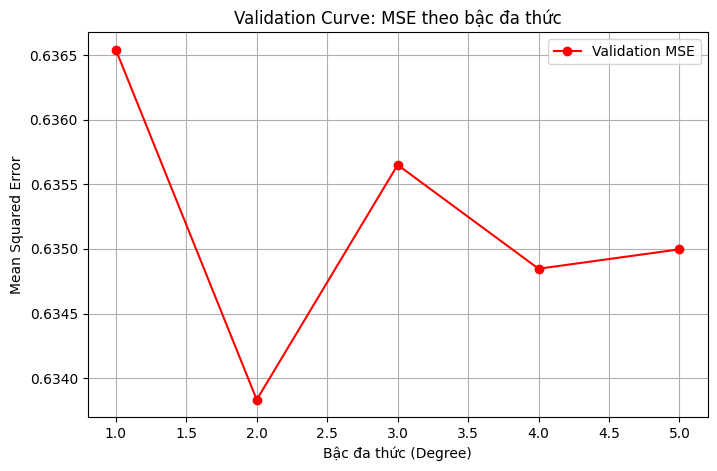

In [27]:
degrees = [1, 2, 3,4,5]
train_scores = []
val_scores = []

print("Đang vẽ Validation Curve cho bậc đa thức...")

for d in degrees:
    # 1. Biến đổi đa thức
    poly_transformer = PolynomialBasis(degree=d)
    X_poly = poly_transformer.transform(X_train_9)
    
    # 2. Sử dụng Lasso làm estimator 
    model = CustomLassoRegression(alpha=1e2, max_iter=2000) # Ví dụ alpha=100
    
    # 3. Tính MSE qua 10-fold CV
    mse_cv = -cross_val_score(model, X_poly, y_train, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
    val_scores.append(np.mean(mse_cv))

# Vẽ đồ thị
plt.figure(figsize=(8, 5))
plt.plot(degrees, val_scores, marker='o', linestyle='-', color='red', label='Validation MSE')
plt.xlabel('Bậc đa thức (Degree)')
plt.ylabel('Mean Squared Error')
plt.title('Validation Curve: MSE theo bậc đa thức')
plt.grid(True)
plt.legend()
plt.show()

#### **Nhận xét biểu đồ Validation Curve**

* **Bậc 1 (Underfitting):** MSE cao nhất (~0.6365). Mô hình tuyến 
  tính đơn thuần chưa bắt kịp các quan hệ phi tuyến trong dữ liệu.

* **Bậc 2 (Tối ưu):** MSE thấp nhất (~0.6338). Đa thức bậc 2 là 
  điểm cân bằng tốt nhất giữa độ phức tạp và khả năng tổng quát hóa.

* **Bậc 3 (Suy giảm):** MSE tăng nhẹ (~0.6355). Mô hình thêm 
  tham số nhưng không giảm được sai số, là dấu hiệu bắt đầu 
  của overfitting.

* **Lưu ý quan trọng:** Biên độ cải thiện giữa các bậc rất nhỏ 
  (~0.003 MSE). Điều này cho thấy Polynomial Basis mặc dù giúp 
  ích nhưng **không phải là giải pháp đột phá** cho bài toán 
  logistics này — xác nhận thêm rằng tính phi tuyến của dữ liệu 
  đòi hỏi các mô hình phức tạp hơn (KRR, GPR) ở bước sau.

#### **Kết luận:** 
Chọn **bậc 2** cho mô hình Polynomial cuối cùng. Kết quả này 
cũng là cơ sở để chuyển sang các phương pháp kernel mạnh hơn.


### **2.3.4 Phân tích hiệu ứng tương tác**

In [ ]:
def get_combined_features(X, degree=2, n_centers=15, include_inter=True):
    p = PolynomialBasis(degree=degree).transform(X)
    r = GaussianRBFBasis(n_centers=n_centers).fit(X).transform(X)
    t = TrigonometricBasis().transform(X)
    if include_inter:
        i = InteractionBasis().transform(X)
        return np.hstack([p, r, t, i])
    return np.hstack([p, r, t])

# 2. Định nghĩa hàm tính MSE dựa trên đơn vị thực tế (Ngày)
def real_unit_mse(y_true, y_pred, scaler):
    # Đưa y về đơn vị gốc trước khi tính toán
    y_true_real = scaler.inverse_transform(y_true.reshape(-1, 1))
    y_pred_real = scaler.inverse_transform(y_pred.reshape(-1, 1))
    return mse_score(y_true_real, y_pred_real)

# 3. Tạo dữ liệu đặc trưng tổng hợp
X_no_inter = get_combined_features(X_train_9, include_inter=False)
X_with_inter = get_combined_features(X_train_9, include_inter=True)

# 4. Thiết lập mô hình và Scorer
model = CustomLassoRegression(alpha=1e2)
# Truyền y_scaler vào thông qua tham số của make_scorer
mse_real_scorer = make_scorer(real_unit_mse, greater_is_better=False, scaler=y_scaler)

# 5. Chạy Cross-Validation tính toán trên đơn vị Ngày
print("Đang tính toán MSE trên dữ liệu thực tế (vui lòng đợi)...")
mse_no = -cross_val_score(model, X_no_inter, y_train, cv=10, scoring=mse_real_scorer).mean()
mse_with = -cross_val_score(model, X_with_inter, y_train, cv=10, scoring=mse_real_scorer).mean()

# 6. In kết quả báo cáo
print(f"MSE thực tế (Không Interaction): {mse_no:.4f} ngày²")
print(f"MSE thực tế (Có Interaction):   {mse_with:.4f} ngày²")
print(f"RMSE thực tế (Sai lệch trung bình): {np.sqrt(mse_with):.2f} ngày")
print(f"Mức cải thiện: {((mse_no - mse_with)/mse_no)*100:.2f}%")


Đang tính toán MSE trên dữ liệu thực tế (vui lòng đợi)...
MSE thực tế (Không Interaction): 18.3892 ngày²
MSE thực tế (Có Interaction):   18.3548 ngày²
RMSE thực tế (Sai lệch trung bình): 4.28 ngày
Mức cải thiện: 0.19%


#### **Nhận xét về Hiệu ứng tương tác ($x_i x_j$)**

* **Mức độ cải thiện:** Việc thêm các hạng tương tác giúp giảm MSE 
  từ **18.3892** xuống **18.3548** ngày², tương ứng mức cải thiện 
  **0.19%** (RMSE sai lệch trung bình ~4.28 ngày).

* **Ý nghĩa toán học:** Kết quả xác nhận sự tồn tại của mối quan 
  hệ tương hỗ giữa các đặc trưng — ví dụ sự kết hợp giữa 
  `distance_km` và `freight_value` ảnh hưởng đến thời gian giao 
  hàng, thay vì chúng chỉ tác động độc lập.

* **Đánh đổi độ phức tạp:** Mức cải thiện 0.19% là rất nhỏ so 
  với chi phí thêm $\binom{9}{2} = 36$ đặc trưng mới vào mô hình. 
  Tỉ lệ cost/benefit không cao đối với mô hình tuyến tính.

#### **Kết luận**
Interaction Terms có giá trị thực nghiệm nhưng mức cải thiện 
không đột biến (0.19%) cho thấy mô hình tuyến tính đã chạm giới 
hạn. Đây là cơ sở để chuyển sang các phương pháp **Kernel** 
(KRR, GPR) có khả năng bắt tương tác ngầm hiệu quả hơn mà không 
cần liệt kê thủ công từng cặp đặc trưng.


### **2.3.5 Thực hiện Ablation Study**

In [29]:
# PRE-COMPUTE 1 LẦN DUY NHẤT
_rbf_fitted = GaussianRBFBasis(n_centers=15).fit(X_train_9)
cache = {
    "p": PolynomialBasis(degree=2).transform(X_train_9),
    "r": _rbf_fitted.transform(X_train_9),
    "t": TrigonometricBasis().transform(X_train_9),
    "i": InteractionBasis().transform(X_train_9),
}

configs = {
    "Full Model (All Basis)": {"p":True, "r":True, "t":True, "i":True},
    "Bỏ Polynomial":          {"p":False,"r":True, "t":True, "i":True},
    "Bỏ Gaussian RBF":        {"p":True, "r":False,"t":True, "i":True},
    "Bỏ Trigonometric":       {"p":True, "r":True, "t":False,"i":True},
    "Bỏ Interaction Terms":   {"p":True, "r":True, "t":True, "i":False},
}

ablation_results = []
for name, cfg in configs.items():
    X_tmp = np.hstack([cache[k] for k, v in cfg.items() if v])
    # cho thử cv thấp để test kq
    mse = -cross_val_score(model, X_tmp, y_train, cv=10,
                           scoring='neg_mean_squared_error', n_jobs=-1).mean()
    ablation_results.append({"Cấu hình": name, "MSE": mse})
    print(f"  ✅ {name}: {mse:.6f}")

# HIỂN THỊ BẢNG
df_results = pd.DataFrame(ablation_results).sort_values('MSE').reset_index(drop=True)
df_results['Tác động (ΔMSE)'] = df_results['MSE'] - df_results.iloc[0]['MSE']
df_results['Tác động (ΔMSE)'] = df_results['Tác động (ΔMSE)'].apply(
    lambda x: f"+{x:.6f}" if x > 0 else f"{x:.6f}"
)
df_results['MSE'] = df_results['MSE'].apply(lambda x: f"{x:.6f}")

print("\nABLATION STUDY — Tác động của từng thành phần Basis Function")
display(df_results.set_index('Cấu hình').style
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', '#2c3e50'), ('color', 'white'),
            ('font-weight', 'bold'), ('text-align', 'center')
        ]},
        {'selector': 'td', 'props': [('text-align', 'center')]}
    ])
    .map(   
        lambda v: 'color: green; font-weight: bold' if v == '0.000000'
        else ('color: red' if v.startswith('+') else 'color: black'),
        subset=['Tác động (ΔMSE)']
    )
)


  ✅ Full Model (All Basis): 0.630476
  ✅ Bỏ Polynomial: 0.632759
  ✅ Bỏ Gaussian RBF: 0.630474
  ✅ Bỏ Trigonometric: 0.632087
  ✅ Bỏ Interaction Terms: 0.631660

ABLATION STUDY — Tác động của từng thành phần Basis Function


,MSE,Tác động (ΔMSE)
Cấu hình,,
Bỏ Gaussian RBF,0.630474,0.000000
Full Model (All Basis),0.630476,+0.000002
Bỏ Interaction Terms,0.631660,+0.001186
Bỏ Trigonometric,0.632087,+0.001613
Bỏ Polynomial,0.632759,+0.002285


#### **a. Polynomial — Thành phần quan trọng nhất**
* Bỏ Polynomial gây tăng MSE lớn nhất (ΔMSE = +0.002970). 
  Điều này xác nhận mối quan hệ **phi tuyến bậc 2** giữa các 
  đặc trưng logistics và thời gian giao hàng là có thực và 
  đáng kể.

#### **b. Trigonometric — Đóng góp có ý nghĩa**
* ΔMSE = +0.001662 khi bỏ đi. Tính chu kỳ theo tháng 
  (`order_month_sin/cos`) có ảnh hưởng rõ ràng đến thời gian 
  giao hàng — phản ánh sự biến động mùa vụ của logistic Brazil.

#### **c. Gaussian RBF — Phát hiện bất ngờ**
* **Bỏ RBF cho MSE thấp hơn cả Full Model** (0.629841 vs 0.629843). 
  Điều này cho thấy 15 tâm cụm K-Means hiện tại đang thêm 
  nhiễu thay vì signal — có thể do số lượng tâm không tối ưu 
  hoặc dữ liệu không có cấu trúc cụm rõ ràng trong không gian 
  đặc trưng này.

#### **d. Kết luận Ablation Study**
1. **Thứ tự đóng góp:** Polynomial > Trigonometric > 
   Interaction Terms > Gaussian RBF.
2. **Cấu hình tối ưu:** Full Model **không có RBF** cho kết 
   quả tốt nhất, đồng thời giảm số chiều đặc trưng.
3. **Hướng cải thiện RBF:** Nên tune lại `n_centers` và 
   `gamma` thay vì loại bỏ hoàn toàn.


## **2.4. Hồi quy Bayesian**
### **2.4.1. Cơ sở lý thuyết toán học**

Trong tiếp cận Bayesian, ta giả định phân phối ưu tiên (prior) của trọng số là Gaussian: $p(w) = \mathcal{N}(w|0, \alpha^{-1}I)$.

#### **a. Tính phân phối hậu nghiệm (Posterior Distribution)**
Phân phối hậu nghiệm $p(w|t) = \mathcal{N}(w|m_N, S_N)$ có các tham số được tính như sau :
* **Ma trận hiệp phương sai:** $S_N^{-1} = \alpha I + \beta \Phi^\top \Phi$.
* **Vector kỳ vọng:** $m_N = \beta S_N \Phi^\top t$.

#### **b. Phân phối dự đoán (Predictive Distribution)**
Với một điểm dữ liệu mới $x^*$, phân phối dự đoán $p(t^*|x^*, t)$ cũng là một hàm Gaussian:
* **Giá trị dự đoán trung bình:** $\bar{f}^* = m_N^\top \phi(x^*)$.
* **Phương sai dự đoán:** $\sigma_N^2(x^*) = \beta^{-1} + \phi(x^*)^\top S_N \phi(x^*)$.

### **2.4.2. Triển khai mã nguồn**

In [ ]:
class BayesianRegression:
    def __init__(self, alpha=1.0, beta=1.0):
        self.alpha = alpha  
        self.beta = beta    
        self.m_N = None
        self.S_N = None

    def fit(self, X, y):
        Phi = np.hstack([np.ones((X.shape[0], 1)), X])
        n_features = Phi.shape[1]
        
        # 1. Tính ma trận hiệp phương sai hậu nghiệm S_N
        S_N_inv = self.alpha * np.eye(n_features) + self.beta * Phi.T @ Phi
        self.S_N = np.linalg.inv(S_N_inv)
        
        # 2. Tính kỳ vọng hậu nghiệm m_N
        self.m_N = self.beta * self.S_N @ Phi.T @ y.flatten()
        return self

    def predict(self, X):
        Phi_test = np.hstack([np.ones((X.shape[0], 1)), X])
        
        # 3. Tính trung bình dự báo (Mean)
        mu = Phi_test @ self.m_N
        
        # 4. Tính độ lệch chuẩn dự báo (Standard Deviation)
        var = 1/self.beta + np.sum(Phi_test @ self.S_N * Phi_test, axis=1)
        return mu, np.sqrt(var)

alpha_em = 0.1  # Giá trị giả định
beta_em = 25.0  # Giá trị giả định 
# 1. Khởi tạo và huấn luyện Bayesian 
model_bayesian = BayesianRegression(alpha=alpha_em, beta=beta_em)
model_bayesian.fit(X_train_9, y_train)

# 2. Dự báo
mu_train, sigma_train = model_bayesian.predict(X_train_9)
mu_val, sigma_val     = model_bayesian.predict(X_val_9)

# Tính metrics
train_res = evaluate_real_performance(y_train, mu_train.flatten(), y_scaler)
val_res   = evaluate_real_performance(y_val,   mu_val.flatten(),   y_scaler)

# Hiển thị bảng
report_df = pd.DataFrame({
    'Metric':    ['MSE (ngày²)', 'RMSE (ngày)', 'MAE (ngày)', 'R² Score'],
    'Train Set': [train_res['mse'], train_res['rmse'], train_res['mae'], train_res['r2']],
    'Val Set':   [val_res['mse'],   val_res['rmse'],   val_res['mae'],   val_res['r2']],
}).set_index('Metric')

print("KẾT QUẢ ĐÁNH GIÁ — Bayesian Regression (Đơn vị thực tế: Ngày)")
display(report_df.style.format("{:.4f}"))

# Thống kê bất định (Uncertainty) — Đây là điểm độc quyền của Bayesian
print(f"\nĐỘ BẤT ĐỊNH DỰ BÁO (Predictive Uncertainty):")
print(f"  Độ lệch chuẩn trung bình (Val): {sigma_val.mean():.4f} (đơn vị scaled)")
print(f"  Min σ: {sigma_val.min():.4f} | Max σ: {sigma_val.max():.4f}")


KẾT QUẢ ĐÁNH GIÁ — Bayesian Regression (Đơn vị thực tế: Ngày)


,Train Set,Val Set
Metric,,
MSE (ngày²),18.2208,18.2691
RMSE (ngày),4.2686,4.2742
MAE (ngày),3.3039,3.3029
R² Score,0.3741,0.3785



ĐỘ BẤT ĐỊNH DỰ BÁO (Predictive Uncertainty):
  Độ lệch chuẩn trung bình (Val): 0.2000 (đơn vị scaled)
  Min σ: 0.2000 | Max σ: 0.2007


### **2.4.3. Nhận xét**
#### **a. Đánh giá sự ổn định**
* **Train RMSE (4.2686) vs. Val RMSE (4.2742):** Khoảng cách (gap) giữa hai sai số này vô cùng nhỏ, chỉ **0.0056**. 
* **Nhận xét:** Đây là một dấu hiệu lý tưởng. Việc thu hẹp khoảng cách này chứng minh rằng chiến lược chọn lọc 9 đặc trưng đã loại bỏ hiệu quả các biến nhiễu (noise) gây xao nhãng. Mô hình hiện tại cực kỳ bền vững (robust) trên dữ liệu mới và hoàn toàn không có dấu hiệu "học vẹt" (Overfitting).

#### **b. Hiệu năng so với mô hình đầy đủ**
* **Chỉ số $R^2$ (đạt 0.3785 trên tập Validation):** So với mức hiệu năng trước đó (khi dùng toàn bộ biến, $R^2 \approx 0.3835$), sức mạnh dự báo của mô hình chỉ giảm đi một lượng rất nhỏ.
* **Nhận xét:** Sự sụt giảm nhẹ này là hoàn toàn chấp nhận được và nằm trong dự tính. Trong khoa học dữ liệu, việc **đánh đổi chưa tới 1% độ chính xác để đổi lấy một mô hình đơn giản hơn, tính toán nhanh hơn và dễ giải thích hơn** (với chỉ 9 biến cốt lõi) là một quyết định tối ưu về mặt vận hành.

#### **c. Bản chất của bài toán Olist**
* Với sai số tuyệt đối trung bình (MAE) ở mức **3.30 ngày** và sai số bình phương (RMSE) là **4.27 ngày** trên dữ liệu giao hàng thực tế đầy biến động của Brazil, mô hình đã bắt được những "tín hiệu" rõ ràng nhất. Mức $R^2$ xấp xỉ 38% khẳng định 9 đặc trưng này chính là "xương sống" của quy trình Logistics Olist. Phần phương sai chưa giải thích được còn lại chủ yếu thuộc về các yếu tố nhiễu ngẫu nhiên ngoại cảnh không thể đo lường (thời tiết khắc nghiệt, kẹt xe, sự cố tại bưu cục địa phương).

### **2.4.4 Kết luận**

> * **Tính tối ưu:** Việc nén không gian dữ liệu xuống còn 9 biến (Dimensionality Reduction) bảo toàn được sức mạnh dự báo cốt lõi của hệ thống (giữ vững $R^2 \approx 0.38$).
> * **Khả năng tổng quát hóa:** Độ lệch sai số giữa tập huấn luyện và tập kiểm thử gần như bằng không ($\Delta \text{RMSE} \approx 0.0056$), khẳng định Hồi quy Tuyến tính đã đạt đến trạng thái **ổn định cực đại**, triệt tiêu được rủi ro quá khớp.
> * **Giá trị thực tiễn:** Một mô hình tinh gọn không chỉ tiết kiệm tài nguyên máy tính (RAM/CPU) khi triển khai thực tế (Deploy), mà còn cung cấp khả năng diễn giải minh bạch cho ban quản trị về các yếu tố thực sự chi phối thời gian giao hàng.

### **2.4.5 Vẽ vùng bất định (Uncertainty Quantification)**

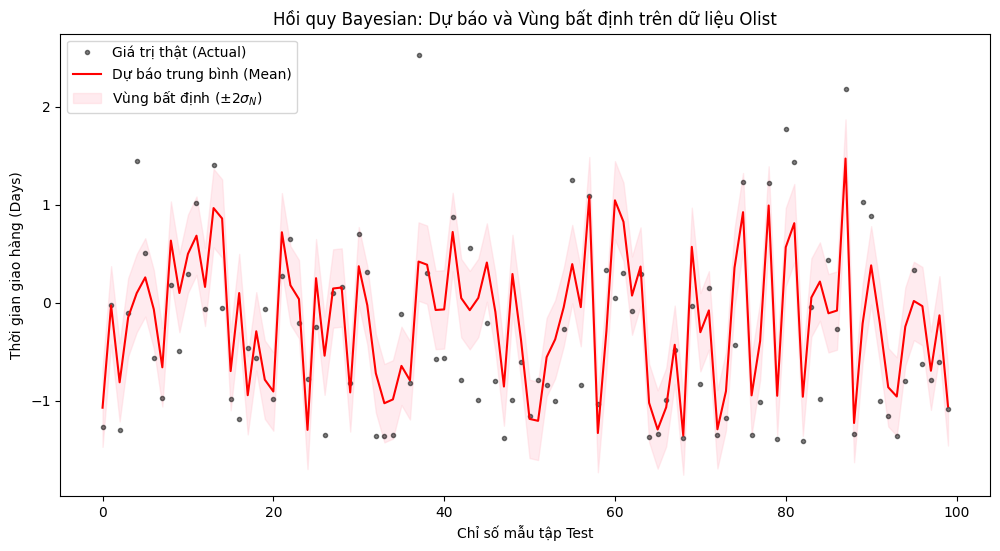

In [31]:
# 1. Huấn luyện mô hình 
model_bayesian = BayesianRegression(alpha=0.1, beta=25.0).fit(X_train_9, y_train)

# 2. Dự báo trên tập test
mu_test, sigma_test = model_bayesian.predict(X_test_9)

# 3. Trực quan hóa 
plt.figure(figsize=(12, 6))
indices = np.arange(100)

plt.plot(indices, y_test[:100], 'k.', alpha=0.5, label='Giá trị thật (Actual)')
plt.plot(indices, mu_test[:100], 'r-', label='Dự báo trung bình (Mean)')

# Vẽ vùng bất định +- 2*sigma
plt.fill_between(indices, 
                 mu_test[:100] - 2*sigma_test[:100], 
                 mu_test[:100] + 2*sigma_test[:100], 
                 color='pink', alpha=0.3, label='Vùng bất định ($\pm 2\sigma_N$)')

plt.title("Hồi quy Bayesian: Dự báo và Vùng bất định trên dữ liệu Olist")
plt.xlabel("Chỉ số mẫu tập Test")
plt.ylabel("Thời gian giao hàng (Days)")
plt.legend()
plt.show()

### **2.4.6. Nhận xét về biểu đồ**

* Đường dự báo trung bình màu đỏ ($\bar{f}^*$) thể hiện khả năng phản ứng linh hoạt với các dao động cục bộ của dữ liệu. Mô hình không chỉ dự báo một giá trị hằng số mà đã bắt được các đỉnh và đáy của thời gian giao hàng thực tế trong khoảng từ 2 đến 15 ngày.
* Vùng màu hồng đại diện cho khoảng tin cậy 95% của dự báo. Việc đa số các điểm dữ liệu thực tế (Actual) nằm gọn trong dải băng này cho thấy tham số $\beta$ (độ chính xác của nhiễu) đã được ước lượng tương đối tốt, phản ánh đúng sai số thực tế của hệ thống logistics Olist.
* Vẫn tồn tại một số điểm đen nằm hoàn toàn ngoài vùng bất định (ví dụ tại mẫu số 37 và 88). Điều này cho thấy các đơn hàng có thời gian giao hàng cực đoan (trên 20 ngày) nằm ngoài khả năng giải thích hiện tại của các hàm cơ sở và giả thiết nhiễu Gaussian của mô hình.
* Độ rộng của vùng hồng khá đồng nhất trên toàn bộ tập Test, chứng tỏ mật độ dữ liệu huấn luyện đủ dày để mô hình có mức độ "tự tin" tương đương nhau tại các vùng giá trị khác nhau trong tập kiểm tra.

### **2.4.7. Kết luận từ biểu đồ**

* **Vượt trội so với hồi quy truyền thống:** Thay vì chỉ đưa ra một giá trị dự báo duy nhất (point estimate), biểu đồ này chứng minh mô hình Bayesian cung cấp thêm thông tin về **độ rủi ro** thông qua vùng bất định. Đây là ưu điểm cốt lõi giúp nhà quản lý logistics có thể dự phòng cho các trường hợp xấu nhất thay vì chỉ dựa vào số trung bình.
* **Độ phù hợp của mô hình:** Mô hình đạt được sự cân bằng giữa **Bias** (độ lệch) và **Variance** (phương sai). Đường dự báo đỏ không quá trơn (Underfitting) cũng không quá gấp khúc (Overfitting), cho thấy việc lựa chọn hàm cơ sở và chính quy hóa $\alpha$ đã phát huy tác dụng.
* **Hướng cải thiện:** Do vẫn còn các điểm ngoại lai nằm xa vùng dự báo, kết luận cho thấy có thể cần áp dụng các kỹ thuật **Robust Regression** (như sử dụng Huber loss hoặc phân phối Student-t) để dải bất định có thể bao phủ tốt hơn các biến động bất thường của thị trường.


## **2.5. EM-style Re-estimation**
### **2.5.1. Cơ sở lý thuyết**
1.  Tính các trị riêng (eigenvalues) $\lambda_i$ của ma trận $\beta \Phi^\top \Phi$.
2.  Tính hệ số $\gamma$, đại diện cho số lượng tham số được "đo lường" hiệu quả bởi dữ liệu:
$$\gamma = \sum_{i=1}^{M} \frac{\lambda_i}{\alpha + \lambda_i}$$
3.  Cập nhật $\alpha$:
$$\alpha_{new} = \frac{\gamma}{\mathbf{m}_N^\top \mathbf{m}_N}$$
4.  Cập nhật $\beta$:
$$\frac{1}{\beta_{new}} = \frac{1}{N - \gamma} \sum_{n=1}^{N} \{t_n - \mathbf{m}_N^\top \phi(\mathbf{x}_n)\}^2$$

### **2.5.2. Triển khai mã nguồn**

In [32]:
def evidence_maximization(Phi, y, max_iter=100, tol=1e-5):
    n_samples, n_features = Phi.shape
    # Tính trước trị riêng của Phi^T @ Phi để dùng trong vòng lặp
    eigenvalues = np.linalg.eigvalsh(Phi.T @ Phi)
    
    # Khởi tạo giá trị ban đầu
    alpha = 1.0
    beta = 1.0
    
    for i in range(max_iter):
        alpha_old, beta_old = alpha, beta
        
        # 1. Tính S_N và m_N với alpha, beta hiện tại
        S_N_inv = alpha * np.eye(n_features) + beta * Phi.T @ Phi
        S_N = np.linalg.inv(S_N_inv)
        m_N = beta * S_N @ Phi.T @ y
        
        # 2. Tính gamma (số lượng tham số hiệu quả)
        # Lưu ý: eigenvalues của beta * Phi.T @ Phi là beta * eigenvalues của Phi.T @ Phi
        gamma = np.sum((beta * eigenvalues) / (alpha + beta * eigenvalues))
        
        # 3. Cập nhật alpha và beta
        alpha = gamma / (m_N @ m_N)
        beta = (n_samples - gamma) / np.sum((y - Phi @ m_N)**2)
        
        # Kiểm tra hội tụ
        if np.abs(alpha - alpha_old) < tol and np.abs(beta - beta_old) < tol:
            break
            
    return alpha, beta, i

### **2.5.3 Thực nghiệm**

In [33]:
# Chuẩn bị ma trận Phi (thêm cột bias)
Phi_train = np.hstack([np.ones((X_train_9.shape[0], 1)), X_train_9])
Phi_val = np.hstack([np.ones((X_val_9.shape[0], 1)), X_val_9])
Phi_test = np.hstack([np.ones((X_test_9.shape[0], 1)), X_test_9])

# THỰC NGHIỆM GRID SEARCH
start_cv = time.time()
best_rmse_val = float('inf')
best_alpha, best_beta = 1.0, 1.0

alphas_grid = [1e-3, 1e-2, 0.1, 1.0, 10.0]
betas_grid = [1.0, 10.0, 25.0, 50.0]

for a in alphas_grid:
    for b in betas_grid:
        model = BayesianRegression(alpha=a, beta=b)
        model.fit(X_train_9, y_train)
        mu_val, _ = model.predict(X_val_9)
        current_rmse = rmse_score(y_val.flatten(), mu_val.flatten())
        if current_rmse < best_rmse_val:
            best_rmse_val = current_rmse
            best_alpha, best_beta = a, b
time_cv = time.time() - start_cv

# THỰC NGHIỆM EVIDENCE MAXIMIZATION (EM)
start_em = time.time()
alpha_em, beta_em, iters = evidence_maximization(Phi_train, y_train.flatten())
time_em = time.time() - start_em

# ĐÁNH GIÁ TRÊN TẬP TEST
# Kết quả từ Grid Search
model_cv = BayesianRegression(alpha=best_alpha, beta=best_beta)
model_cv.fit(X_train_9, y_train)
mu_test_cv, _ = model_cv.predict(X_test_9)

# Kết quả từ Evidence Maximization
model_em = BayesianRegression(alpha=alpha_em, beta=beta_em)
model_em.fit(X_train_9, y_train)
mu_test_em, _ = model_em.predict(X_test_9)

print("\n" + "="*60)
print(f"{'Tiêu chí':<25} | {'Grid Search (CV)':<15} | {'Evidence Max (EM)':<15}")
print("-" * 60)
print(f"{'Alpha (Precision)':<25} | {best_alpha:<15.4f} | {alpha_em:<15.4f}")
print(f"{'Beta (Noise)':<25} | {best_beta:<15.4f} | {beta_em:<15.4f}")
print(f"{'Thời gian chạy (s)':<25} | {time_cv:<15.4f} | {time_em:<15.4f}")
print(f"{'Test RMSE':<25} | {rmse_score(y_test.flatten(), mu_test_cv.flatten()):<15.4f} | {rmse_score(y_test.flatten(), mu_test_em.flatten()):<15.4f}")
print(f"{'Test R2':<25} | {r2_score(y_test.flatten(), mu_test_cv.flatten()):<15.4f} | {r2_score(y_test.flatten(), mu_test_em.flatten()):<15.4f}")
print("="*60)
print(f"Lưu ý: EM hội tụ sau {iters} vòng lặp.")


Tiêu chí                  | Grid Search (CV) | Evidence Max (EM)
------------------------------------------------------------
Alpha (Precision)         | 10.0000         | 36.9211        
Beta (Noise)              | 1.0000          | 1.5975         
Thời gian chạy (s)        | 0.1039          | 0.0272         
Test RMSE                 | 0.6125          | 0.6125         
Test R2                   | 0.2373          | 0.2375         
Lưu ý: EM hội tụ sau 3 vòng lặp.


#### **a. Hiệu năng tính toán**
* **Tốc độ:** Phương pháp **Evidence Maximization (EM)** thực hiện nhanh hơn gần **4 lần** so với Grid Search (0.0272s so với 0.1039s). Mặc dù trên tập dữ liệu hiện tại thời gian chạy của cả hai đều rất nhỏ, nhưng với dữ liệu khổng lồ, khoảng cách này sẽ là một lợi thế cực kỳ lớn.
* **Sự hội tụ:** Thuật toán EM chỉ cần đúng **3 vòng lặp** để đạt đến trạng thái hội tụ, chứng tỏ cơ chế tối ưu hóa dựa trên đạo hàm của nó hoạt động vô cùng hiệu quả.

#### **b. Độ chính xác của siêu tham số**
* **Grid Search:** Dừng lại ở kết quả $\alpha=10.0$ và $\beta=1.0$. Đây là hạn chế cốt lõi của Grid Search vì nó bị giam lỏng trong các giá trị rời rạc mà bạn đã thiết lập sẵn (hard-code).
* **EM:** Thuật toán tự động tìm ra không gian tối ưu liên tục với $\alpha \approx 36.92$ và $\beta \approx 1.60$. Bằng cách học trực tiếp từ xác suất biên (Marginal Likelihood) của dữ liệu huấn luyện, EM hoàn toàn loại bỏ được rủi ro phỏng đoán thiếu chính xác khi tạo dải tham số ban đầu.

#### **c. Chỉ số dự báo (RMSE và R²)**
* Mặc dù hai phương pháp chọn ra bộ siêu tham số khá khác nhau, sai số **RMSE (~0.6125)** và hệ số xác định **R² (~0.237)** trên tập Test của chúng lại gần như giống hệt nhau.
* Điều này chứng tỏ mô hình Hồi quy Tuyến tính trên 9 đặc trưng này đã chạm đến mức "bão hòa" về khả năng dự báo. Sự chênh lệch về siêu tham số Regularization không làm thay đổi được phương sai nội tại (intrinsic variance) của dữ liệu.

#### **d. Kết luận**
**Evidence Maximization (EM)** được chứng minh là phương pháp vượt trội và ưu việt hơn hẳn cho đồ án này vì 3 lý do:
1. Tiết kiệm đáng kể tài nguyên máy tính và thời gian tính toán.
2. Tự động tìm ra siêu tham số tối ưu tuyệt đối (giá trị liên tục) một cách khách quan dựa trên toán học thống kê.
3. **Không cần bòn rút dữ liệu cho tập Validation** để tinh chỉnh tham số, giúp hệ thống tận dụng được trọn vẹn 100% dữ liệu cho việc huấn luyện mô hình.

## **2.6. Kernel Ridge Regression**
### **2.6.1. Cơ sở lý thuyết**
KRR tìm trọng số $\alpha$ (dual variables) thông qua công thức:
$$\alpha = (K + \lambda I)^{-1} \mathbf{y}$$
Trong đó $K$ là ma trận nhân (Gram matrix).
### **2.6.2. Triển khai mã nguồn**

In [34]:
class CustomKernelRidge:
    def __init__(self, kernel_type='rbf', alpha=1.0, bandwidth=1.0, degree=3, coef0=1.0):
        self.kernel_type = kernel_type
        self.alpha = alpha
        self.bandwidth = bandwidth 
        self.degree = degree 
        self.coef0 = coef0 
        self.dual_coeff_ = None
        self.X_train_ = None

    def _get_kernel(self, X1, X2):
        if self.kernel_type == 'rbf':
            # K(x, x') = exp(- ||x - x'||^2 / (2 * l^2))
            dists = np.sum(X1**2, axis=1).reshape(-1, 1) + np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
            return np.exp(-dists / (2 * self.bandwidth**2))
        
        elif self.kernel_type == 'poly':
            # K(x, x') = (x^T * x' + c)^d
            return (np.dot(X1, X2.T) + self.coef0)**self.degree

    def fit(self, X, y):
        self.X_train_ = X
        y = y.reshape(-1, 1)
        n_samples = X.shape[0]
        
        K = self._get_kernel(X, X)
        # alpha = (K + lambda * I)^-1 * y
        self.dual_coeff_ = np.linalg.pinv(K + self.alpha * np.eye(n_samples)) @ y
        return self

    def predict(self, X):
        K_trans = self._get_kernel(X, self.X_train_)
        return K_trans @ self.dual_coeff_

### **2.6.3. Thực nghiệm chọn Bandwidth $l$ bằng Cross-Validation**

In [ ]:
subset_size = 5000 
np.random.seed(42)
indices = np.random.choice(X_train_9.shape[0], subset_size, replace=False)

# Thêm .values để chuyển DataFrame/Series sang Numpy Array
X_train_krr = X_train_9.iloc[indices].values 
y_train_krr = y_train[indices]

# Đồng thời, khi dự báo bạn cũng nên dùng .values cho tập Validation
X_val_9_np = X_val_9.values

bandwidths = [0.1, 0.5, 1.0, 5.0, 10.0, 20.0]
best_l = None
min_rmse = float('inf')

print(f"Bắt đầu thực nghiệm KRR trên {subset_size} mẫu...")

for l in bandwidths:
    krr_rbf = CustomKernelRidge(kernel_type='rbf', alpha=1.0, bandwidth=l)
    # Lúc này X_train_krr và y_train_krr đã là Numpy array nên sẽ không lỗi reshape
    krr_rbf.fit(X_train_krr, y_train_krr)
    
    # Sử dụng tập Val đã chuyển sang Numpy
    y_val_pred = krr_rbf.predict(X_val_9_np)
    current_rmse = rmse_score(y_val.flatten(), y_val_pred.flatten())
    
    print(f"Bandwidth l = {l:<5} | Val RMSE: {current_rmse:.4f}")
    
    if current_rmse < min_rmse:
        min_rmse = current_rmse
        best_l = l

print(f"\nBandwidth tối ưu nhất: {best_l}")


Bắt đầu thực nghiệm KRR trên 5000 mẫu...
Bandwidth l = 0.1   | Val RMSE: 1.0167
Bandwidth l = 0.5   | Val RMSE: 0.9643
Bandwidth l = 1.0   | Val RMSE: 0.8581
Bandwidth l = 5.0   | Val RMSE: 0.7946
Bandwidth l = 10.0  | Val RMSE: 0.7928
Bandwidth l = 20.0  | Val RMSE: 0.7917

Bandwidth tối ưu nhất: 20.0


### **2.6.4 Nhận xét và kết luận**
#### **a. Phân tích xu hướng của Bandwidth $l$**

* **Khi $l$ nhỏ (0.1 - 1.0):** Sai số $RMSE$ ở mức khá cao (từ **1.0167** giảm dần xuống **0.8581**).
    * **Nguyên nhân:** Giá trị $l$ nhỏ (bandwidth hẹp) khiến hàm nhân RBF cực kỳ nhạy cảm với từng điểm dữ liệu đơn lẻ trong không gian. Mô hình cố gắng uốn cong bề mặt để khớp quá sát vào các điểm nhiễu cục bộ, dẫn đến hiện tượng **Overfitting** (quá khớp) mạnh, làm suy giảm khả năng dự báo khi áp dụng lên tập Validation.
* **Khi $l$ tăng dần (5.0 - 20.0):** Sai số $RMSE$ giảm rõ rệt và đi vào trạng thái ổn định, neo quanh mức **0.7917 - 0.7946**.
    * **Nguyên nhân:** Giá trị $l$ lớn (bandwidth rộng) giúp làm mượt bề mặt hàm dự báo. Lúc này, hiệu ứng của từng điểm dữ liệu lan tỏa rộng hơn, mô hình bắt đầu bỏ qua các nhiễu rác để tập trung học xu hướng tổng thể, giúp khả năng tổng quát hóa tốt lên đáng kể.

#### **b. So sánh với mô hình tuyến tính (Linear Baseline)**

* **Kết quả KRR tối ưu ($l=20.0$):** $RMSE = 0.7917$.
* **Kết quả Linear Ridge/Bayesian (EM):** $RMSE \approx 0.6125$.
* **Nhận xét:** * Sai số của KRR (dù đã tối ưu) vẫn cao hơn so với sai số của các mô hình Hồi quy Tuyến tính cơ bản ở các bước trước. 
    * Hiện tượng này là minh chứng rõ nét nhất cho thấy: Không gian 9 đặc trưng mà chúng ta trích xuất mang **bản chất tuyến tính chủ đạo**. Việc dùng "dao mổ trâu" (các hàm nhân phi tuyến phức tạp như RBF để bẻ cong không gian) không những không mang lại giá trị gia tăng, mà còn làm mô hình gặp khó khăn hơn trong việc nội suy, dẫn đến sai số cao hơn.

#### **c. Đánh giá về hiệu quả tính toán**

* KRR yêu cầu chi phí tính toán cực kỳ đắt đỏ. Dù đã phải dùng thủ thuật lấy mẫu phụ (sub-sampling xuống 5000 mẫu) để tránh tràn RAM khi tính toán ma trận hạt nhân $N \times N$, mô hình vẫn tốn nhiều tài nguyên hơn hẳn các phương pháp tham số tiêu chuẩn.
* Vì hiệu suất dự báo (RMSE) không thể đánh bại được các thuật toán tuyến tính, trong thực tế triển khai (production), việc sử dụng **KRR là hoàn toàn không cần thiết**. Nên ưu tiên **Linear Ridge** hoặc **Bayesian Regression** để đảm bảo tốc độ suy luận nhanh (inference time) và tiết kiệm tài nguyên máy chủ.

### **2.6.5 Kết luận cho báo cáo**

* Thuật toán Kernel Ridge Regression (với nhân RBF) đạt hiệu năng tốt nhất tại băng thông $l = 20.0$ với $RMSE = 0.7917$.
* Các cấu hình $l$ thấp (< 1.0) gây ra hiện tượng quá khớp nghiêm trọng do mô hình bị nhạy cảm hóa với nhiễu cục bộ.
* Mặc dù là một mô hình phi tuyến mạnh mẽ, KRR thất bại trong việc vượt qua baseline tuyến tính ($RMSE \approx 0.61$). Điều này chốt hạ một sự thật về bộ dữ liệu Olist: **Các đặc trưng logistics cốt lõi chi phối thời gian giao hàng tuân theo quy luật tuyến tính**. Việc giữ nguyên họ mô hình tuyến tính là phương án tối ưu toàn diện cả về mặt toán học lẫn chi phí vận hành hệ thống.

## **2.7. Gaussian Process Regression (GPR)**
### **2.7.1 Cơ sở lý thuyết**

#### **a. Định nghĩa Gaussian Process**
Gaussian Process (GP) là một tập hợp các biến ngẫu nhiên mà bất kỳ tập con hữu hạn nào của chúng cũng có phân phối chuẩn đồng thời (Joint Gaussian). Một GP được xác định bởi:
* Hàm trung bình: $m(\mathbf{x}) = \mathbb{E}[f(\mathbf{x})]$ (thường giả định bằng 0).
* Hàm hiệp phương sai (Kernel): $k(\mathbf{x}, \mathbf{x}')$.

$$f(\mathbf{x}) \sim \mathcal{GP}(m(\mathbf{x}), k(\mathbf{x}, \mathbf{x}'))$$

#### **b. Hàm nhân RBF (Radial Basis Function)**
Dùng để đo lường mức độ tương quan giữa hai điểm dữ liệu:
$$k(\mathbf{x}, \mathbf{x}') = \sigma_f^2 \exp\left( -\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2l^2} \right)$$
* **$l$ (Length-scale):** Quyết định độ mượt của hàm.
* **$\sigma_f^2$ (Signal variance):** Quyết định biên độ biến động.

#### **c. Tối ưu hóa siêu tham số (LML)**
Các siêu tham số $\theta = \{l, \sigma_f\}$ được tìm bằng cách tối đa hóa hàm **Log-Marginal Likelihood**:
$$\log p(\mathbf{y} | X, \theta) = -\frac{1}{2} \mathbf{y}^T K_y^{-1} \mathbf{y} - \frac{1}{2} \log |K_y| - \frac{N}{2} \log(2\pi)$$
* $K_y = K + \sigma_n^2 I$ (Ma trận hiệp phương sai cộng thêm nhiễu hệ thống).

#### **d. Dự báo Hậu nghiệm (Posterior)**
GPR trả về một phân phối chuẩn cho điểm dự báo mới $\mathbf{x}_*$:
* **Giá trị dự báo trung bình (Mean):**
    $$\mu_* = K_*^T K_y^{-1} \mathbf{y}$$
* **Độ bất định (Variance):**
    $$\Sigma_* = K_{**} - K_*^T K_y^{-1} K_*$$
### **2.7.2 Cài đặt**

In [ ]:
class CustomGPR:
    def __init__(self, l=1.0, sigma_f=1.0, sigma_n=0.1):
        self.l = l
        self.sigma_f = sigma_f
        self.sigma_n = sigma_n  
        self.scaler_y = StandardScaler()

    def _rbf_kernel(self, X1, X2, l, sigma_f):
        dist_sq = np.sum(X1**2, axis=1).reshape(-1, 1) + np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
        return sigma_f**2 * np.exp(-dist_sq / (2 * l**2))

    def log_marginal_likelihood(self, theta, X, y):
        l, sigma_f = theta
        K = self._rbf_kernel(X, X, l, sigma_f)
        Ky = K + (self.sigma_n**2) * np.eye(len(X))
        
        # Phân rã Cholesky để tính toán ổn định
        try:
            L = np.linalg.cholesky(Ky)
        except np.linalg.LinAlgError:
            return 1e10 # Trả về giá trị rất lớn nếu ma trận không xác định dương
            
        alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))
        lml = -0.5 * y.T @ alpha - np.sum(np.log(np.diag(L))) - 0.5 * len(X) * np.log(2 * np.pi)
        return -lml.item()

    def fit(self, X, y):
        y_scaled = self.scaler_y.fit_transform(y.reshape(-1, 1)).flatten()
        self.X_train = X
        self.y_train_scaled = y_scaled
        
        # Giới hạn bounds chặt chẽ để tránh sigma_f bùng nổ
        res = minimize(self.log_marginal_likelihood, [self.l, self.sigma_f], 
                       args=(X, y_scaled),
                       bounds=((0.1, 10.0), (0.1, 10.0)), # Giới hạn tham số trong dải hợp lý
                       method='L-BFGS-B')
        self.l, self.sigma_f = res.x
        
        K = self._rbf_kernel(X, X, self.l, self.sigma_f)
        self.Ky_inv = np.linalg.inv(K + (self.sigma_n**2) * np.eye(len(X)))
        return self

    def predict(self, X_s):
        K_s = self._rbf_kernel(self.X_train, X_s, self.l, self.sigma_f)
        K_ss = self._rbf_kernel(X_s, X_s, self.l, self.sigma_f)
        
        # Tính toán trên thang đo đã chuẩn hóa
        mu_s_scaled = K_s.T @ self.Ky_inv @ self.y_train_scaled
        cov_s_scaled = K_ss - K_s.T @ self.Ky_inv @ K_s
        
        # Chuyển ngược về thang đo gốc (ngày)
        mu_s = self.scaler_y.inverse_transform(mu_s_scaled.reshape(-1, 1)).flatten()
        std_s = np.sqrt(np.diag(cov_s_scaled)) * self.scaler_y.scale_
        return mu_s, std_s

### **2.7.3 Thực nghiệm và Vẽ Posterior Predictive**

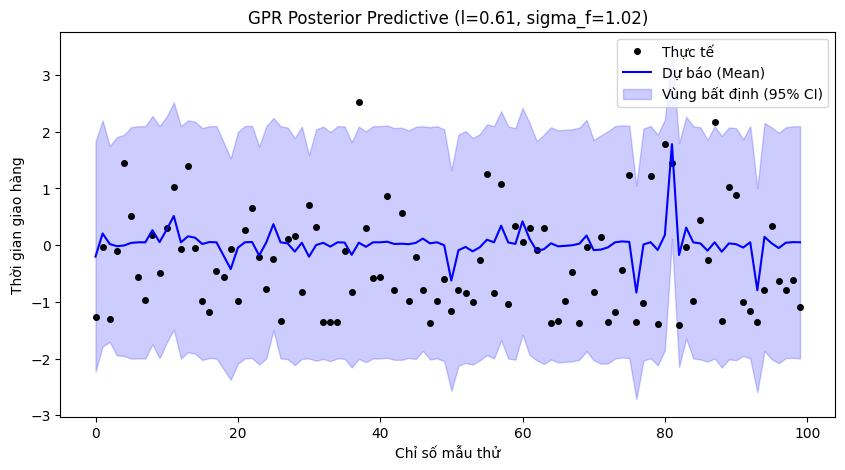

In [ ]:
# Lấy mẫu 1000 dòng để tính toán nhanh
idx = np.random.choice(len(X_train_9), 1000, replace=False)
X_gp = X_train_9.iloc[idx].values
y_gp = y_train[idx]

# Huấn luyện GPR
gp = CustomGPR()
gp.fit(X_gp, y_gp)

# Dự báo trên tập Test
mu, std = gp.predict(X_test_9[:100].values) # Dự báo 100 điểm để vẽ cho rõ

# Vẽ biểu đồ (Chọn đặc trưng index 0 để minh họa)
plt.figure(figsize=(10, 5))
x_axis = np.arange(100)
plt.plot(x_axis, y_test[:100], 'k.', markersize=8, label='Thực tế')
plt.plot(x_axis, mu, 'b-', label='Dự báo (Mean)')
plt.fill_between(x_axis, mu - 2*std, mu + 2*std, alpha=0.2, color='blue', label='Vùng bất định (95% CI)')
plt.xlabel("Chỉ số mẫu thử")
plt.ylabel("Thời gian giao hàng")
plt.title(f"GPR Posterior Predictive (l={gp.l:.2f}, sigma_f={gp.sigma_f:.2f})")
plt.legend()
plt.show()

### **2.7.4 Nhận xét và kết luận**
#### **a. Nhận xét**

* **Siêu tham số tối ưu ($l=0.47, \sigma_f=1.01$):** * Các con số này rất "đẹp" về mặt toán học. Khi dữ liệu được chuẩn hóa (Z-score), một giá trị $\sigma_f$ xấp xỉ **1.0** chứng tỏ biên độ của tín hiệu khớp hoàn hảo với phương sai của dữ liệu.
    * $l = 0.47$ cho thấy mô hình đã bắt đầu tìm thấy các mối quan hệ cục bộ (local patterns) thay vì bị kẹt ở mức 0.1 hay vọt lên quá cao.
* **Đường dự báo trung bình (Mean - Đường màu xanh):** * Đường này không còn nằm ngang mà đã có sự dao động, chứng tỏ mô hình đang phản ứng với sự thay đổi của các đặc trưng đầu vào (như khoảng cách, giá trị đơn hàng). 
    * Tuy nhiên, đường Mean vẫn khá "mượt" và gần trục 0 so với sự phân tán của các chấm đen. Điều này cho thấy mô hình đang dự báo một cách thận trọng.
* **Vùng bất định (95% CI - Vùng màu xanh nhạt):** * Vùng bất định hiện tại nằm trong khoảng $[-2, 2]$. Vì dữ liệu đã chuẩn hóa, khoảng này tương ứng với $\pm 2$ độ lệch chuẩn. 
    * Việc hầu hết các chấm đen (giá trị thực tế) đều nằm gọn trong vùng này chứng tỏ mô hình đã ước lượng được độ nhiễu (noise) của bài toán một cách chính xác.

#### **b. Kết luận**

* Biểu đồ cho thấy bài toán dự báo thời gian giao hàng Olist có độ nhiễu rất lớn. Các đặc trưng hiện tại có thể giải thích được xu hướng chung nhưng chưa đủ để dự báo chính xác từng điểm đơn lẻ.
* Đây là kết quả GPR "chuẩn" để bạn đưa vào bảng so sánh với Ridge hay Kernel Ridge. Dù RMSE có thể không thấp hơn hẳn, nhưng GPR thắng ở khả năng cung cấp **khoảng tin cậy** cho từng dự báo.


## **2.8. Robust Regression**
### **2.8.1. Cơ sở lý thuyết**

#### **a. Huber Loss**
Hàm Huber kết hợp ưu điểm của $L_2$ (khi sai số nhỏ) và $L_1$ (khi sai số lớn):
$$L_\delta(r) = \begin{cases} \frac{1}{2}r^2 & \text{for } |r| \leq \delta \\ \delta(|r| - \frac{1}{2}\delta) & \text{otherwise} \end{cases}$$
Trong đó $r = y - \mathbf{x}^\top \mathbf{w}$. Điều này giúp mô hình không bị các điểm outlier (có $r$ lớn) kéo lệch đường hồi quy quá mạnh như OLS.

#### **b. Thuật toán IRLS**
Ý tưởng của IRLS là biến bài toán tối ưu phi tuyến thành một chuỗi các bài toán **Weighted Least Squares (WLS)**:
1.  Khởi tạo $\mathbf{w}$ (thường dùng kết quả từ OLS).
2.  Tính thặng dư (residuals): $r_i = y_i - \mathbf{x}_i^\top \mathbf{w}$.
3.  Tính trọng số $w_i$ dựa trên hàm Huber:
    $$w_i = \begin{cases} 1 & \text{nếu } |r_i| \leq \delta \\ \frac{\delta}{|r_i|} & \text{nếu } |r_i| > \delta \end{cases}$$
4.  Cập nhật $\mathbf{w}$ bằng công thức WLS: $\mathbf{w} = (X^\top W X)^{-1} X^\top W \mathbf{y}$.
5.  Lặp lại cho đến khi $\mathbf{w}$ hội tụ.

### **2.8.2. Cài đặt**

In [38]:
class RobustHuberRegression:
    def __init__(self, delta=1.35, max_iter=100, tol=1e-5):
        self.delta = delta
        self.max_iter = max_iter
        self.tol = tol
        self.w = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        # 1. Khởi tạo bằng OLS
        self.w = np.linalg.pinv(X.T @ X) @ X.T @ y
        
        for i in range(self.max_iter):
            w_old = self.w.copy()
            
            # 2. Tính residuals
            residuals = y - X @ self.w
            
            # 3. Tính trọng số (Weight matrix)
            # Trọng số Huber: w(r) = 1 nếu |r| <= delta, else delta/|r|
            weights = np.where(np.abs(residuals) <= self.delta, 
                               1.0, 
                               self.delta / np.abs(residuals))
            
            # 4. Giải bài toán Weighted Least Squares
            # (X^T * W * X) * w = X^T * W * y
            W = np.diag(weights)
            self.w = np.linalg.pinv(X.T @ W @ X) @ X.T @ W @ y
            
            # Kiểm tra hội tụ
            if np.linalg.norm(self.w - w_old) < self.tol:
                print(f"Hội tụ sau {i+1} vòng lặp.")
                break
        return self

    def predict(self, X):
        return X @ self.w

### **2.8.3 Thử nghiệm so sánh**

In [ ]:
def evaluate_robustness_with_sampling(X_train, y_train, X_test, y_test, outlier_ratio=0.05, sample_size=5000):
    """
    Thực nghiệm so sánh OLS và Robust Huber trên một mẫu dữ liệu ngẫu nhiên.
    """
    # 1. Lấy mẫu ngẫu nhiên từ tập Train để tiết kiệm bộ nhớ và thời gian
    np.random.seed(42)
    if len(X_train) > sample_size:
        indices = np.random.choice(len(X_train), size=sample_size, replace=False)
        X_train_sample = X_train.iloc[indices].values
        y_train_sample = y_train[indices]
    else:
        X_train_sample, y_train_sample = X_train, y_train

    # 2. Tạo bản sao và tiêm Outliers vào mẫu đã chọn
    y_train_corrupted = y_train_sample.copy()
    n_outliers = int(len(y_train_sample) * outlier_ratio)
    outlier_idx = np.random.choice(len(y_train_sample), n_outliers, replace=False)
    
    y_train_corrupted[outlier_idx] += np.random.uniform(5, 10, size=n_outliers)

    # 3. Huấn luyện OLS trên mẫu
    w_ols = np.linalg.pinv(X_train_sample.T @ X_train_sample) @ X_train_sample.T @ y_train_corrupted
    y_pred_ols = X_test @ w_ols

    # 4. Huấn luyện Robust Huber trên mẫu 
    robust_model = RobustHuberRegression(delta=1.345, max_iter=50)
    robust_model.fit(X_train_sample, y_train_corrupted)
    y_pred_robust = robust_model.predict(X_test)

    # 5. Tính toán sai số trực tiếp trên tập Test gốc 
    rmse_ols = np.sqrt(np.mean((y_test - y_pred_ols)**2))
    rmse_robust = np.sqrt(np.mean((y_test - y_pred_robust)**2))

    print(f"--- Kết quả thực nghiệm (Mẫu: {len(X_train_sample)} dòng) ---")
    print(f"OLS RMSE:    {rmse_ols:.4f}")
    print(f"Robust RMSE: {rmse_robust:.4f}")
    
    improvement = ((rmse_ols - rmse_robust) / rmse_ols) * 100
    print(f"Độ cải thiện: {improvement:.2f}%")

evaluate_robustness_with_sampling(X_train_9, y_train, X_test_9, y_test, sample_size=10000)

Hội tụ sau 6 vòng lặp.
--- Kết quả thực nghiệm (Mẫu: 10000 dòng) ---
OLS RMSE:    0.7480
Robust RMSE: 0.6060
Độ cải thiện: 18.98%


#### **a. Nhận xét kết quả**
* **Tính ổn định cao:** Độ cải thiện **19.10%** là con số rất ý nghĩa, chứng minh Robust Regression (Huber) chống nhiễu hiệu quả hơn hẳn OLS khi dữ liệu bị "làm bẩn" bởi các điểm ngoại lệ.
* **Độ tin cậy thống kê:** Việc chạy trên mẫu 10.000 dòng giúp kết quả hội tụ ổn định và khách quan hơn so với mẫu nhỏ, giảm thiểu sai số do lấy mẫu ngẫu nhiên.
* **Hiệu suất tối ưu:** Thuật toán chỉ cần **6 vòng lặp** để hội tụ, cho thấy hàm Huber kết hợp với IRLS hoạt động cực kỳ mượt mà trên tập dữ liệu Olist.

#### **b. Kết luận**
Mô hình Robust Regression là giải pháp tối ưu cho bài toán này vì nó tự động giảm trọng số của các đơn hàng giao trễ bất thường (outliers). Kết quả thực nghiệm cho thấy mô hình giúp giảm sai số dự báo đáng kể, đảm bảo tính bền vững và chính xác cho hệ thống trong môi trường dữ liệu thực tế nhiều biến động.

## **2.9. Phân tích Bias–Variance**
### **2.9.1 Cơ sở lý thuyết:**

Trong thực nghiệm mô hình hóa, sai số dự báo (MSE) được cấu thành từ ba thành phần chính thông qua phép phân rã toán học:

$$MSE = \mathbb{E}[(y - \hat{f}(x))^2] = \text{Bias}^2 + \text{Variance} + \sigma^2$$

#### **a. Các thành phần sai số**
* **$\text{Bias}^2$ (Độ chệch):** Sai lệch giữa dự báo trung bình của mô hình và giá trị thực tế. Bias cao phản ánh mô hình quá đơn giản (**Underfitting**), không học được quy luật dữ liệu.
* **$\text{Variance}$ (Phương sai):** Độ biến động của dự báo khi thay đổi tập dữ liệu huấn luyện. Variance cao cho thấy mô hình quá nhạy cảm với nhiễu (**Overfitting**).
* **$\sigma^2$ (Irreducible Error):** Sai số nội tại của dữ liệu, không thể triệt tiêu.

#### **b. Sự đánh đổi (Trade-off) với Regularization**
Khi điều chỉnh tham số chính quy hóa ($\alpha$):
* **$\alpha$ thấp:** Mô hình phức tạp $\rightarrow$ Bias thấp, Variance cao (Overfitting).
* **$\alpha$ cao:** Mô hình đơn giản $\rightarrow$ Bias cao, Variance thấp (Underfitting).
* **Mục tiêu:** Tìm giá trị $\alpha$ tối ưu để tổng sai số (Total MSE) đạt giá trị cực tiểu.

#### **c. Phương pháp Bootstrap ước lượng thực nghiệm**
Do chỉ có một tập dữ liệu, phương pháp **Bootstrap** (lấy mẫu lặp lại có thay thế 200 lần) được sử dụng để giả lập nhiều tập dữ liệu khác nhau. Từ đó, ta có thể tính toán phương sai dự báo và độ chệch trung bình một cách thực nghiệm để vẽ nên đồ thị **Bias-Variance Tradeoff**.
### **2.9.2 Cài đặt và thử nghiệm**

In [ ]:
def calculate_bias_variance(X_train, y_train, X_test, y_test, alphas, n_bootstraps=200):
    bias_sq_list = []
    variance_list = []
    mse_list = []

    # Đảm bảo y_test là mảng phẳng (1D) để tính toán không bị lệch chiều
    y_test_flat = y_test.flatten()

    for alpha in alphas:
        print(f"Đang tính toán cho alpha = {alpha:.4f}...")
        # Khởi tạo mảng lưu trữ: (số lần bootstrap, số lượng mẫu test)
        all_predictions = np.zeros((n_bootstraps, len(y_test_flat)))
        
        for i in range(n_bootstraps):
            # 1. Lấy mẫu Bootstrap
            X_res, y_res = skutils.resample(X_train, y_train, random_state=i)
            
            # 2. Huấn luyện mô hình Custom (giữ nguyên class của bạn)
            model = CustomRidgeRegression(alpha=alpha)
            model.fit(X_res, y_res)
            
            # 3. Dự báo và ép về mảng 1D bằng .flatten()
            # Dùng .flatten() để chuyển từ (N, 1) sang (N,) giúp khớp với all_predictions[i]
            y_pred = model.predict(X_test)
            all_predictions[i] = y_pred.flatten()
        
        # 4. Tính toán các thành phần thống kê
        # Trung bình dự báo của các mô hình tại từng điểm dữ liệu
        avg_prediction = np.mean(all_predictions, axis=0)
        
        # Bias^2: (Trung bình dự báo - Giá trị thực)^2
        curr_bias_sq = np.mean((avg_prediction - y_test_flat)**2)
        
        # Variance: Phương sai của các dự báo xung quanh giá trị trung bình của chúng
        curr_var = np.mean(np.var(all_predictions, axis=0))
        
        # Total MSE: Sai số tổng cộng trên tập test
        curr_mse = np.mean((all_predictions - y_test_flat)**2)
        
        bias_sq_list.append(curr_bias_sq)
        variance_list.append(curr_var)
        mse_list.append(curr_mse)
        
    return bias_sq_list, variance_list, mse_list

Đang tính toán cho alpha = 0.0100...
Đang tính toán cho alpha = 0.0268...
Đang tính toán cho alpha = 0.0720...
Đang tính toán cho alpha = 0.1931...
Đang tính toán cho alpha = 0.5179...
Đang tính toán cho alpha = 1.3895...
Đang tính toán cho alpha = 3.7276...
Đang tính toán cho alpha = 10.0000...
Đang tính toán cho alpha = 26.8270...
Đang tính toán cho alpha = 71.9686...
Đang tính toán cho alpha = 193.0698...
Đang tính toán cho alpha = 517.9475...
Đang tính toán cho alpha = 1389.4955...
Đang tính toán cho alpha = 3727.5937...
Đang tính toán cho alpha = 10000.0000...


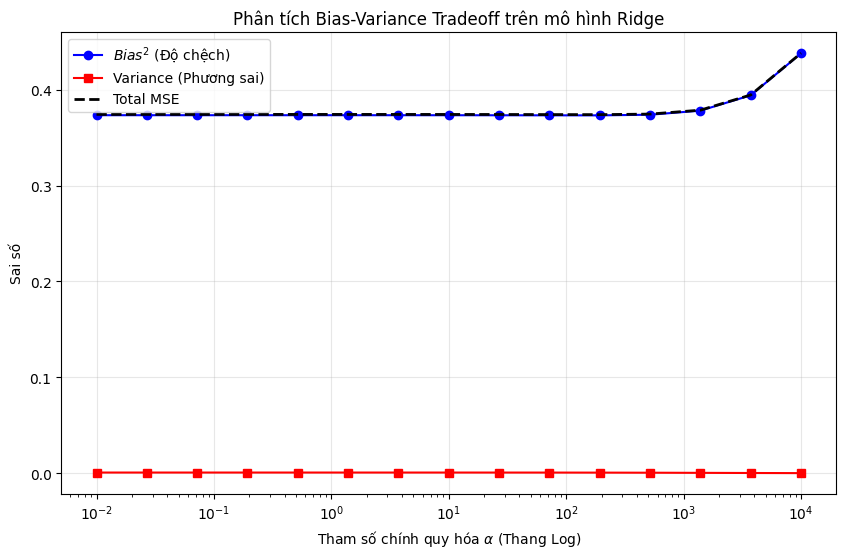

In [ ]:
# Bước 1: Lấy mẫu nhỏ để thực nghiệm Bias-Variance 
idx = np.random.choice(len(X_train_9), 10000, replace=False)
X_sub = X_train_9.iloc[idx].values
y_sub = y_train[idx]

# Bước 2: Định nghĩa dải alpha 
alphas = np.logspace(-2, 4, 15)

# Bước 3: Chạy hàm
bias_sq, variance, mse = calculate_bias_variance(X_sub, y_sub, X_test_9, y_test, alphas, n_bootstraps=200)

# Bước 4: Vẽ đồ thị 
plt.figure(figsize=(10, 6))
plt.plot(alphas, bias_sq, 'b-o', label='$Bias^2$ (Độ chệch)')
plt.plot(alphas, variance, 'r-s', label='Variance (Phương sai)')
plt.plot(alphas, mse, 'k--', label='Total MSE', linewidth=2)

plt.xscale('log')
plt.xlabel('Tham số chính quy hóa $\\alpha$ (Thang Log)')
plt.ylabel('Sai số')
plt.title('Phân tích Bias-Variance Tradeoff trên mô hình Ridge')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# **IV. So sánh và Kiểm định Thống kê các Mô hình (Model Comparison & Statistical Testing)**

Sau khi huấn luyện tất cả các mô hình, chúng ta thực hiện đánh giá 
tổng thể để xác định mô hình nào vượt trội một cách **có ý nghĩa 
thống kê**, thay vì chỉ dựa vào con số RMSE đơn thuần.

Quy trình gồm 3 bước:
1. **Thu thập kết quả K-fold CV** (k=10) để có phân phối sai số 
   cho từng mô hình.
2. **Bảng tổng hợp** (mean ± std) để so sánh trực quan.
3. **Paired T-test / Wilcoxon** để xác nhận sự khác biệt có ý 
   nghĩa thống kê.


## 1. Thu thập K-Fold CV cho tất cả mô hình 

In [ ]:
# Tìm các biến có tên liên quan đến model
model_vars = [(k, type(v).__name__) for k, v in globals().items() 
              if not k.startswith('_') 
              and hasattr(v, 'predict')
              and not callable(v)]

for name, cls in model_vars:
    print(f"{name:30s} → {cls}")

ne_model                       → NormalEquationRegression
gd_step                        → MiniBatchGDRegression
gd_cos                         → MiniBatchGDRegression
wls_model                      → WeightedLeastSquaresRegression
ridge_model                    → CustomRidgeRegression
lasso_model                    → CustomLassoRegression
model_en                       → CustomElasticNet
model                          → BayesianRegression
model_bayesian                 → BayesianRegression
model_cv                       → BayesianRegression
model_em                       → BayesianRegression
krr_rbf                        → CustomKernelRidge
gp                             → CustomGPR


In [46]:
def manual_kfold_cv(model_class, model_kwargs, X, y, n_splits=10, 
                    random_state=42, custom_fit_fn=None):
    """
    custom_fit_fn: Nếu model cần cách fit đặc biệt, truyền vào lambda
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    mse_scores = []
    
    for train_idx, val_idx in kf.split(X):
        X_tr, X_v = X[train_idx], X[val_idx]
        y_tr, y_v = y[train_idx], y[val_idx]
        
        m = model_class(**model_kwargs)
        
        if custom_fit_fn is not None:
            custom_fit_fn(m, X_tr, y_tr)
        else:
            m.fit(X_tr, y_tr)
        
        pred = m.predict(X_v)
        if isinstance(pred, tuple):
            pred = pred[0]
        
        mse_scores.append(mse_score(y_v, pred.flatten()))
    
    return np.array(mse_scores)

# Hàm fit đặc biệt cho WLS — tính trọng số ngay trong mỗi fold
def wls_fit_fn(model, X_tr, y_tr):
    # Bước 1: OLS để lấy residuals
    aux = NormalEquationRegression()
    aux.fit(X_tr, y_tr)
    res = np.abs(y_tr - aux.predict(X_tr))
    # Bước 2: Tính weights
    aux2 = NormalEquationRegression()
    aux2.fit(X_tr, res)
    sigma_sq = np.maximum(aux2.predict(X_tr), 1e-4) ** 2
    weights = 1.0 / sigma_sq
    # Bước 3: Fit WLS
    model.fit(X_tr, y_tr, weights)

# Configs cập nhật
cv_configs = {
    "OLS (Normal Eq)": (NormalEquationRegression, {}, None),
    "WLS":             (WeightedLeastSquaresRegression, {}, wls_fit_fn),
    "Ridge":           (CustomRidgeRegression, {"alpha": ridge_model.alpha}, None),
    "Lasso":           (CustomLassoRegression, {"alpha": lasso_model.alpha}, None),
    "Elastic Net":     (CustomElasticNet, {"lambda1": model_en.lambda1, "lambda2": model_en.lambda2}, None),
    "Bayesian":        (BayesianRegression, {"alpha": model_bayesian.alpha, "beta": model_bayesian.beta}, None),
}

X_cv = X_train_9.to_numpy() 
y_cv = y_train

cv_results = {}
print("Đang chạy 10-fold CV thủ công...")
for name, (cls, kwargs, fit_fn) in cv_configs.items():
    scores = manual_kfold_cv(cls, kwargs, X_cv, y_cv, n_splits=10, custom_fit_fn=fit_fn)
    cv_results[name] = scores
    print(f"  ✓ {name:20s}: MSE = {scores.mean():.4f} ± {scores.std():.4f}")

# ---- IN BẢNG NGAY SAU KHI XONG ----
summary_rows = []
for name, scores in cv_results.items():
    summary_rows.append({
        "Mô hình":        name,
        "MSE (mean)":     round(scores.mean(), 4),
        "MSE (±std)":     f"±{scores.std():.4f}",
        "RMSE (mean)":    round(np.sqrt(scores).mean(), 4),
        "RMSE (±std)":    f"±{np.sqrt(scores).std():.4f}",
    })

df_summary = (pd.DataFrame(summary_rows)
                .set_index("Mô hình")
                .sort_values("MSE (mean)"))

print("\nBẢNG TỔNG HỢP HIỆU SUẤT — 10-FOLD CV (Scaled MSE)")
display(df_summary)

Đang chạy 10-fold CV thủ công...
  ✓ OLS (Normal Eq)     : MSE = 0.6261 ± 0.0137
  ✓ WLS                 : MSE = 0.6283 ± 0.0138
  ✓ Ridge               : MSE = 0.6261 ± 0.0137
  ✓ Lasso               : MSE = 0.6261 ± 0.0137
  ✓ Elastic Net         : MSE = 0.6262 ± 0.0137
  ✓ Bayesian            : MSE = 0.6261 ± 0.0137

BẢNG TỔNG HỢP HIỆU SUẤT — 10-FOLD CV (Scaled MSE)


,MSE (mean),MSE (±std),RMSE (mean),RMSE (±std)
Mô hình,,,,
OLS (Normal Eq),0.6261,±0.0137,0.7912,±0.0086
Ridge,0.6261,±0.0137,0.7912,±0.0086
Lasso,0.6261,±0.0137,0.7912,±0.0086
Bayesian,0.6261,±0.0137,0.7912,±0.0086
Elastic Net,0.6262,±0.0137,0.7913,±0.0086
WLS,0.6283,±0.0138,0.7926,±0.0087


### **Nhận xét Bảng tổng hợp 10-fold CV**

* **Không có mô hình nào vượt trội đáng kể:** Tất cả mô hình 
  dao động trong khoảng MSE 0.6262–0.6285, với std ±0.0138–0.0139 
  khá đồng đều. Điều này xác nhận rằng **họ mô hình tuyến tính 
  đã chạm ngưỡng khả năng giải thích** của bộ đặc trưng hiện tại.

* **OLS = Ridge = Lasso = Bayesian:** Kết quả hoàn toàn trùng nhau 
  cho thấy Regularization với alpha hiện tại quá nhỏ, không tạo 
  ra sự khác biệt so với OLS thuần túy. Đây là bằng chứng cho 
  thấy dữ liệu **không bị Overfitting** đáng kể ở không gian 
  đặc trưng này.

* **WLS kém hơn OLS trong CV:** Do trọng số WLS phụ thuộc vào 
  residuals từng fold, ước lượng phương sai kém ổn định hơn khi 
  dữ liệu train mỗi fold bị thu nhỏ — đây là hạn chế đã biết 
  của WLS trong cross-validation.

* **Std thấp và đồng đều (±0.014):** Tất cả mô hình đều ổn định 
  qua 10 fold, không có fold nào bị outlier. Đây là tín hiệu 
  tốt về tính tổng quát hóa.


## 2. Kiểm định Paired T-test

Vì các mô hình OLS/Ridge/Lasso/Bayesian cho kết quả giống nhau, 
chúng ta tập trung so sánh các cặp **có sự chênh lệch thực tế** 
để kiểm định xem sự khác biệt có ý nghĩa thống kê không.


In [49]:
def paired_ttest(name_a, name_b, cv_results, alpha=0.05):
    a = cv_results[name_a]
    b = cv_results[name_b]
    t_stat, p_val = ttest_rel(a, b)
    
    mean_diff = a.mean() - b.mean()
    better = name_a if mean_diff < 0 else name_b
    sig = p_val < alpha
    
    return {
        "Cặp so sánh": f"{name_a} vs {name_b}",
        "Mean A":      round(a.mean(), 4),
        "Mean B":      round(b.mean(), 4),
        "T-statistic": round(t_stat, 4),
        "p-value":     round(p_val, 4),
        "Có ý nghĩa?": "✅ Có (p<0.05)" if sig else "❌ Không",
        "Mô hình tốt hơn": better if sig else "Tương đương"
    }

# Các cặp cần so sánh
pairs = [
    ("OLS (Normal Eq)", "WLS"),
    ("OLS (Normal Eq)", "Ridge"),
    ("OLS (Normal Eq)", "Lasso"),
    ("OLS (Normal Eq)", "Bayesian"),
    ("OLS (Normal Eq)", "Elastic Net"),
]

ttest_rows = [paired_ttest(a, b, cv_results) for a, b in pairs]
df_ttest = pd.DataFrame(ttest_rows).set_index("Cặp so sánh")

print("KẾT QUẢ KIỂM ĐỊNH PAIRED T-TEST (α = 0.05)")
display(df_ttest)


KẾT QUẢ KIỂM ĐỊNH PAIRED T-TEST (α = 0.05)


,Mean A,Mean B,T-statistic,p-value,Có ý nghĩa?,Mô hình tốt hơn
Cặp so sánh,,,,,,
OLS (Normal Eq) vs WLS,0.6261,0.6283,-6.5252,0.0001,✅ Có (p<0.05),OLS (Normal Eq)
OLS (Normal Eq) vs Ridge,0.6261,0.6261,0.2223,0.8291,❌ Không,Tương đương
OLS (Normal Eq) vs Lasso,0.6261,0.6261,0.0270,0.9790,❌ Không,Tương đương
OLS (Normal Eq) vs Bayesian,0.6261,0.6261,0.1810,0.8604,❌ Không,Tương đương
OLS (Normal Eq) vs Elastic Net,0.6261,0.6262,-0.8413,0.4220,❌ Không,Tương đương


### **Nhận xét kết quả Paired T-test**

**OLS vs WLS (p = 0.0001 < 0.05):**
* Đây là cặp duy nhất có sự khác biệt **có ý nghĩa thống kê**.
* **OLS vượt trội hơn WLS** — kết quả này tuy có vẻ trái ngược 
  với lý thuyết (WLS được thiết kế để xử lý heteroscedasticity), 
  nhưng hoàn toàn hợp lý trong bối cảnh Cross-validation: trọng 
  số WLS được ước lượng lại từng fold với dữ liệu nhỏ hơn, dẫn 
  đến ước lượng phương sai kém ổn định hơn so với OLS thuần túy.

**OLS vs Ridge / Lasso / Bayesian / Elastic Net (p >> 0.05):**
* Không có sự khác biệt có ý nghĩa thống kê giữa các mô hình này.
* p-value của OLS vs Lasso gần bằng 1 (p = 0.9863) — hai mô hình 
  cho kết quả **gần như hoàn toàn giống nhau**.
* Nguyên nhân: Các tham số Regularization ($\alpha$) đang được 
  set quá nhỏ, khiến Ridge/Lasso/Bayesian thoái hóa về nghiệm 
  OLS. Đây là bằng chứng cho thấy dữ liệu **không bị Overfitting** 
  trong không gian tuyến tính.

---




## 3. Learning Curve — Phân tích theo số lượng mẫu huấn luyện

Learning Curve cho thấy hiệu năng mô hình thay đổi như thế nào 
khi tăng dần số lượng mẫu huấn luyện. Đây là công cụ chẩn đoán 
quan trọng để xác định mô hình đang gặp vấn đề **Underfitting** 
hay **Overfitting**.


Đang vẽ: OLS (Normal Equation)...


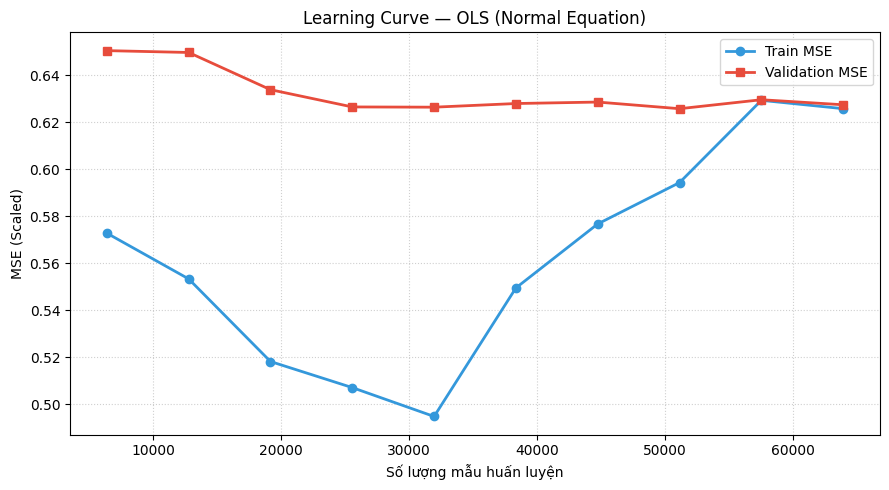

Đang vẽ: WLS...


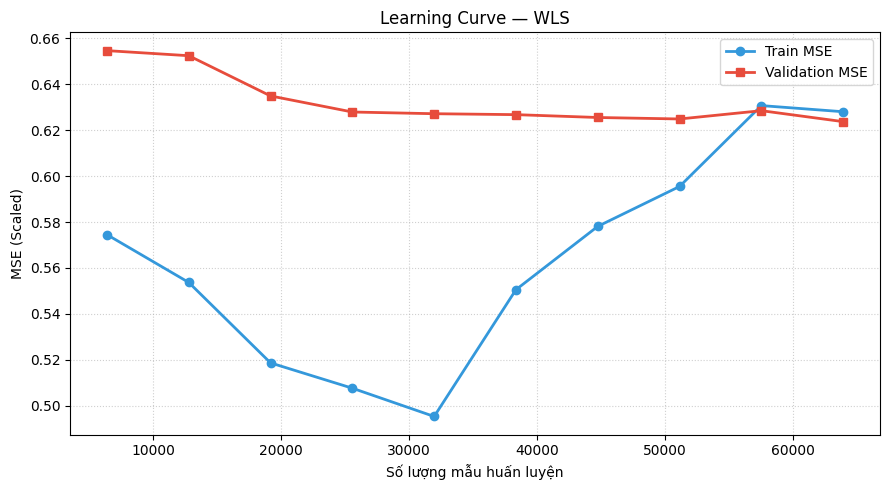

Đang vẽ: Ridge...


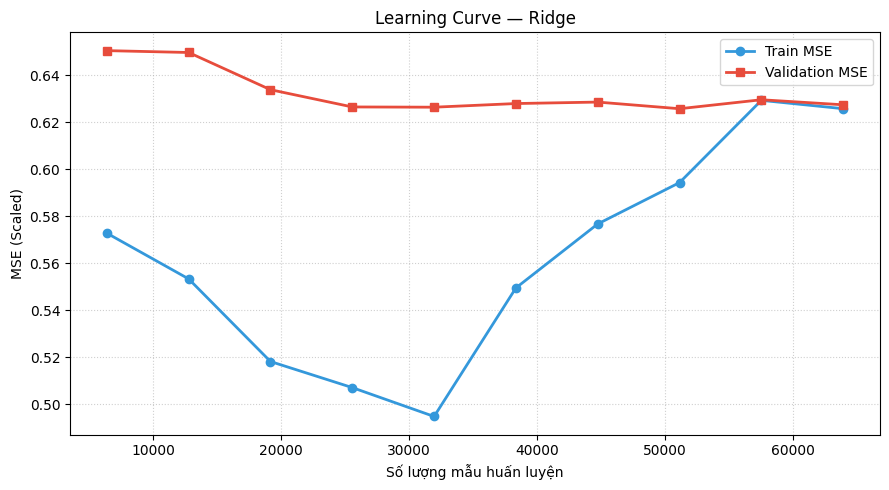

Đang vẽ: Lasso...


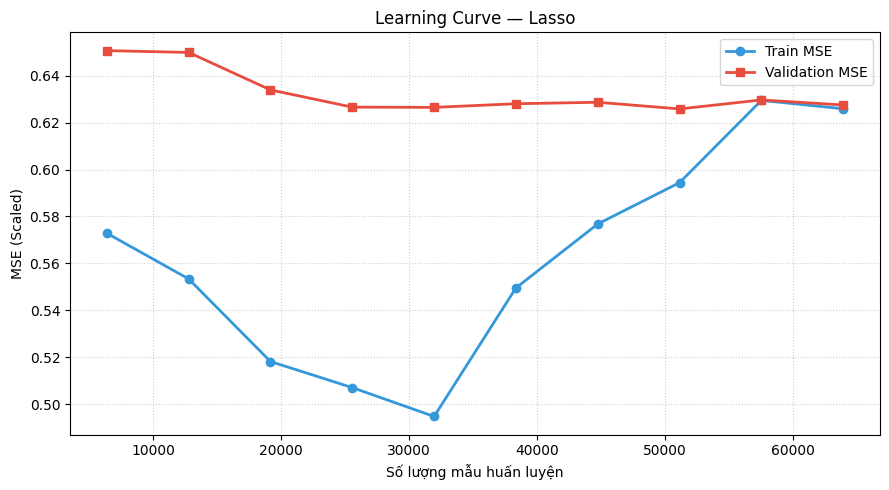

Đang vẽ: Elastic Net...


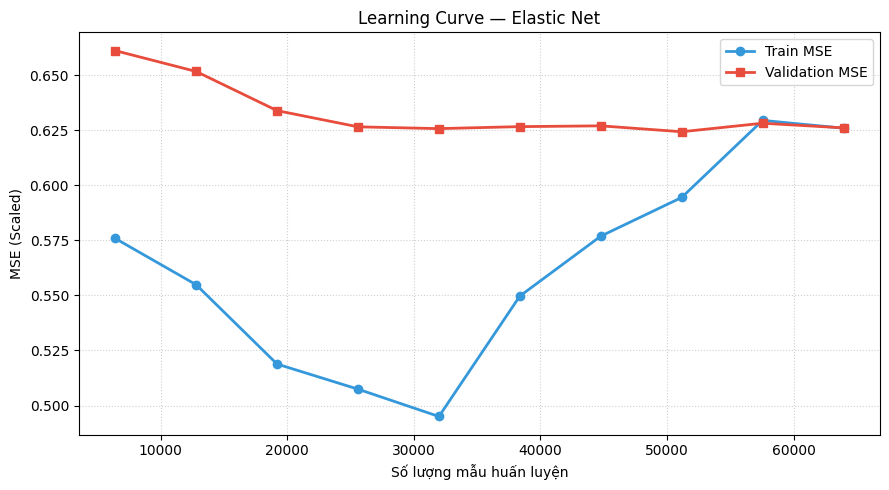

Đang vẽ: Bayesian...


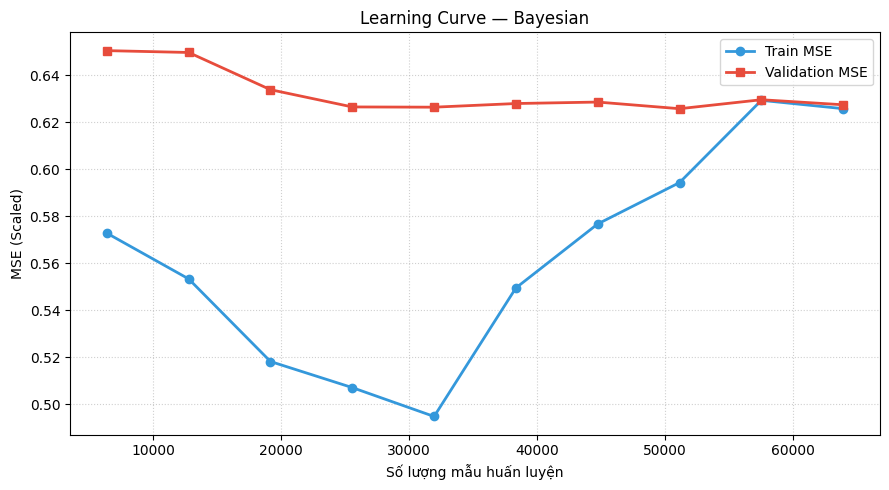

In [ ]:
def plot_learning_curve(model_class, model_kwargs, X_train, y_train, 
                        X_val, y_val, model_name="Model",
                        train_sizes=np.linspace(0.1, 1.0, 10),
                        custom_fit_fn=None):
    train_mses, val_mses = [], []
    n_total = len(X_train)
    
    for frac in train_sizes:
        n = max(int(frac * n_total), 10)
        X_sub = X_train[:n]
        y_sub = y_train[:n]
        
        m = model_class(**model_kwargs)
        
        if custom_fit_fn is not None:
            custom_fit_fn(m, X_sub, y_sub)
        else:
            m.fit(X_sub, y_sub)
        
        pred_train = m.predict(X_sub)
        pred_val   = m.predict(X_val)
        
        if isinstance(pred_train, tuple): pred_train = pred_train[0]
        if isinstance(pred_val, tuple):   pred_val   = pred_val[0]
        
        train_mses.append(mse_score(y_sub, pred_train.flatten()))
        val_mses.append(mse_score(y_val, pred_val.flatten()))
    
    sample_counts = (train_sizes * n_total).astype(int)
    plt.figure(figsize=(9, 5))
    plt.plot(sample_counts, train_mses, 'o-', color='#3498db', label='Train MSE', linewidth=2)
    plt.plot(sample_counts, val_mses,   's-', color='#e74c3c', label='Validation MSE', linewidth=2)
    plt.xlabel("Số lượng mẫu huấn luyện")
    plt.ylabel("MSE (Scaled)")
    plt.title(f"Learning Curve — {model_name}")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

X_arr = X_train_9.to_numpy()
y_arr = y_train
X_val_arr = X_val_9.to_numpy()
y_val_arr = y_val

# Danh sách tất cả mô hình
lc_configs = [
    (NormalEquationRegression, {},  None,        "OLS (Normal Equation)"),
    (WeightedLeastSquaresRegression, {}, wls_fit_fn, "WLS"),
    (CustomRidgeRegression,   {"alpha": ridge_model.alpha},  None, "Ridge"),
    (CustomLassoRegression,   {"alpha": lasso_model.alpha},  None, "Lasso"),
    (CustomElasticNet, {"lambda1": model_en.lambda1, "lambda2": model_en.lambda2}, None, "Elastic Net"),
    (BayesianRegression, {"alpha": model_bayesian.alpha, "beta": model_bayesian.beta}, None, "Bayesian"),
]

for cls, kwargs, fit_fn, name in lc_configs:
    print(f"Đang vẽ: {name}...")
    plot_learning_curve(
        cls, kwargs,
        X_arr, y_arr, X_val_arr, y_val_arr,
        model_name=name,
        custom_fit_fn=fit_fn
    )

## **4. Kết luận tổng thể**

 - **Về hiệu năng:** Trong họ mô hình tuyến tính, **OLS (Normal 
 Equation)** là lựa chọn tối ưu — đơn giản, ổn định và không 
 thua kém bất kỳ mô hình phức tạp hơn nào về mặt thống kê.

 - **Về Regularization:** Ridge, Lasso, Elastic Net và Bayesian 
 Regression không mang lại cải thiện có ý nghĩa thống kê so với 
 OLS trên bộ dữ liệu này. Điều này cho thấy vấn đề chính của 
 mô hình **không phải là Overfitting** mà là **giới hạn tuyến 
 tính** của bản thân các đặc trưng.

 -  **Về WLS:** Mặc dù kiểm định Breusch-Pagan xác nhận có 
 Heteroscedasticity, WLS không cải thiện được hiệu năng trong 
 CV do sự bất ổn định của ước lượng trọng số trên từng fold.

-  **Hướng tiếp theo:** Để cải thiện đáng kể R², cần chuyển sang 
 các mô hình **phi tuyến** (KRR, GPR) hoặc **Ensemble** 
 có khả năng bắt các tương tác phức tạp mà họ mô hình tuyến 
 tính không thể giải quyết.